1. [Настройка среды и путей](#block-01-setup)
2. [Подготовка квартального набора данных](#block-02-data)
3. [Базовое сравнение моделей](#block-03-base-models)
4. [Расширенный SARIMAX с внешними факторами](#block-04-sarimax-exog)
5. [Интерпретация выбранных факторов](#block-05-factor-analysis)
6. [Прогноз до начала 2027 года](#block-06-future-forecast)
7. [Графики итогового прогноза](#block-07-forecast-plots)
9. [Таблицы для практической части](#block-08-tables)

In [3]:
from pathlib import Path
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

try:

    from prophet import Prophet

    PROPHET_AVAILABLE = True

except Exception as e:

    PROPHET_AVAILABLE = False

    print("Prophet не установлен. Установи: pip install prophet")

    print(e)

try:

    from lightgbm import LGBMRegressor

    LIGHTGBM_AVAILABLE = True

except Exception as e:

    LIGHTGBM_AVAILABLE = False

    print("LightGBM не установлен. Установи: pip install lightgbm")

    print(e)

In [6]:
data_dir = Path.cwd() / "dataset"

data_file = data_dir / "demand_training_with_physical_volume.csv"

if not data_file.exists():
    data_file = data_dir / "demand_primary_training_minimal_with_ppi.csv"

if not data_file.exists():
    data_file = data_dir / "demand_primary_training_minimal.csv"

out_dir = data_dir / "model_comparison_with_exog_equal_conditions"

out_dir.mkdir(parents=True, exist_ok=True)

forecast_file = out_dir / "forecasts_models_with_exog.csv"
model_file = out_dir / "overall_metrics_models_with_exog.csv"
product_metrics_file = out_dir / "product_metrics_models_with_exog.csv"
group_metrics_file = out_dir / "category_metrics_models_with_exog.csv"
best_product_file = out_dir / "best_model_by_product_with_exog.csv"
best_group_file = out_dir / "best_model_by_category_with_exog.csv"
OUT_MODEL_PLOT = out_dir / "overall_model_wape_with_exog_bw.png"
OUT_CATEGORY_PLOT = out_dir / "category_best_model_wape_with_exog_bw.png"

out_dir

PosixPath('/home/senya/projects/diplom/dataset/model_comparison_with_exog_equal_conditions')

In [8]:
target = "target_demand_index"
drop_outliers = True
outlier_products = ["Молочные напитки"]

min_train = 12
max_cv = 3
horizon = 4

raw_factors = [
    "consumer_price_index",
    "income_index",
    "stock_days_mean",
    "stock_value_mean_thousand_rub",
    "ppi_product_index",
    "ppi_product_index_quarter_mean",
    "ppi_quarterly_index",
    "physical_volume_index",
]

MAX_EXOG_FEATURES_PER_PRODUCT = 5

TUNE_PROPHET = True
TUNE_SARIMAX = True

PROPHET_GRID = [
    {"changepoint_prior_scale": 0.01, "seasonality_prior_scale": 1.0},
    {"changepoint_prior_scale": 0.05, "seasonality_prior_scale": 5.0},
    {"changepoint_prior_scale": 0.10, "seasonality_prior_scale": 10.0},
]

SARIMAX_ORDER_GRID = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
]

SARIMAX_SEASONAL_ORDER_GRID = [
    (0, 0, 0, 4),
    (1, 0, 0, 4),
    (0, 0, 1, 4),
    (1, 0, 1, 4),
]

In [10]:
def calc_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def calc_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def calc_wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator * 100


def period_end_date(period):

    return period.to_timestamp(how="end").normalize()

## Блок 2. Подготовка квартального набора данных

In [13]:
df = pd.read_csv(data_file)

df = df.rename(
    columns={
        "sales_product_code": "product_code",
        "sales_product_name": "product_name",
        "product_group_name": "group_name",
        "physical_volume_cumulative_yoy_index": "physical_volume_index",
    }
)

df["period_end"] = pd.to_datetime(df["period_end"])
df["period"] = df["period_end"].dt.to_period("Q")
df["year"] = df["period"].dt.year
df["quarter"] = df["period"].dt.quarter

df = df.sort_values(["product_name", "period"]).copy()

if drop_outliers:
    df = df[~df["product_name"].isin(outlier_products)].copy()

required_cols = [
    "product_name",
    "period",
    "period_end",
    "year",
    "quarter",
    target,
]

raw_cols = [col for col in raw_factors if col in df.columns]

print("строк:", len(df))
print("товаров:", df["product_name"].nunique())
print("период:", df["period"].min(), "—", df["period"].max())

строк: 607
товаров: 18
период: 2017Q1 — 2025Q4


In [30]:
df.head()

,period_end,year,quarter,product_code,product_name,group_code,group_name,sales_quarter_thousand_rub,sales_index,consumer_price_index,...,ppi_product_index_quarter_mean_lag4_minus_market,ppi_product_index_quarter_mean_lag4_div_market,ppi_quarterly_index_lag4_minus_group,ppi_quarterly_index_lag4_div_group,ppi_quarterly_index_lag4_minus_market,ppi_quarterly_index_lag4_div_market,physical_volume_index_lag4_minus_group,physical_volume_index_lag4_div_group,physical_volume_index_lag4_minus_market,physical_volume_index_lag4_div_market
0,2017-03-31,2017,1,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,318147374.6,100.000000,105.627924,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-06-30,2017,2,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,373643153.6,117.443419,106.865372,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-09-30,2017,3,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,421984581.1,132.638084,108.124455,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-12-31,2017,4,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,521008272.3,163.763185,109.377408,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-03-31,2018,1,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,379426655.7,119.261288,108.974459,...,NaN,NaN,NaN,NaN,NaN,NaN,-1.242,0.987894,0.577222,1.005728


In [14]:
df = df.sort_values(["product_name", "period"]).copy()

lag_cols = []

for col in raw_cols:
    lag_col = f"{col}_lag4"
    df[lag_col] = df.groupby("product_name")[col].shift(4)
    lag_cols.append(lag_col)

print("Lag4-факторы:")

for col in lag_cols:
    print(col)

Lag4-факторы:
consumer_price_index_lag4
income_index_lag4
stock_days_mean_lag4
stock_value_mean_thousand_rub_lag4
ppi_product_index_quarter_mean_lag4
ppi_quarterly_index_lag4
physical_volume_index_lag4


In [15]:
def get_full_years(product_df):
    year_counts = (
        product_df[product_df[target].notna()].groupby("year")["quarter"].nunique()
    )

    return sorted(year_counts[year_counts == 4].index.tolist())


def get_cv_years(product_df):
    full_years = get_full_years(product_df)
    eligible_years = []

    for year in full_years:
        train_end = pd.Period(f"{year - 1}Q4", freq="Q")
        train_obs = product_df[
            (product_df["period"] <= train_end) & (product_df[target].notna())
        ]

        if len(train_obs) >= min_train:
            eligible_years.append(year)

    return eligible_years[-max_cv:]


product_cv_years = {}

for product_name, product_df in df.groupby("product_name"):
    cv_years = get_cv_years(product_df)

    if len(cv_years) > 0:
        product_cv_years[product_name] = cv_years

cv_info = pd.DataFrame(
    [
        {
            "product_name": product_name,
            "cv_years": "; ".join(map(str, years)),
            "folds": len(years),
        }
        for product_name, years in product_cv_years.items()
    ]
).sort_values("product_name")

display(cv_info)

,product_name,cv_years,folds
0,Автомобили легковые,2023; 2024; 2025,3
1,Бензины автомобильные,2020; 2021,2
2,Газовое моторное топливо,2020; 2021; 2022,3
3,Дизельное топливо,2020; 2021; 2022,3
4,"Консервы молочные, молочные составные сухие, с...",2023; 2024; 2025,3
5,"Лампы накаливания (включая галогенные, кроме л...",2022; 2023; 2024,3
6,Макаронные изделия,2023; 2024; 2025,3
7,Маргариновая продукция,2023; 2024; 2025,3
8,Молоко питьевое,2023; 2024; 2025,3
9,Мука,2023; 2024; 2025,3


In [16]:
def select_exog_features(product_df, train_periods, candidate_cols):

    if not candidate_cols:
        return []

    product_indexed = product_df.set_index("period").sort_index()
    train_exog = product_indexed.reindex(train_periods)[candidate_cols].copy()
    kept = []

    for col in candidate_cols:
        coverage = train_exog[col].notna().mean()
        nunique = train_exog[col].nunique(dropna=True)

        if coverage >= 0.50 and nunique > 1:
            kept.append(col)

    if len(kept) == 0:
        return []

    coverage_rank = train_exog[kept].notna().mean().sort_values(ascending=False)

    kept = coverage_rank.index.tolist()[:MAX_EXOG_FEATURES_PER_PRODUCT]

    return kept


def build_exog_matrices(product_df, train_periods, forecast_periods, exog_cols):
    """
    Возвращает стандартизированные train/future exog.
    Стандартизация обучается только на train.
    """

    if not exog_cols:

        return None, None, []

    product_indexed = product_df.set_index("period").sort_index()

    train_exog = product_indexed.reindex(train_periods)[exog_cols].copy()

    future_exog = product_indexed.reindex(forecast_periods)[exog_cols].copy()

    train_exog = train_exog.astype(float).replace([np.inf, -np.inf], np.nan)

    future_exog = future_exog.astype(float).replace([np.inf, -np.inf], np.nan)

    medians = train_exog.median(numeric_only=True)

    train_exog = train_exog.ffill().bfill().fillna(medians).fillna(0)

    future_exog = future_exog.ffill().bfill().fillna(medians).fillna(0)

    scaler = StandardScaler()

    train_scaled = pd.DataFrame(
        scaler.fit_transform(train_exog),
        index=train_exog.index,
        columns=train_exog.columns,
    )

    future_scaled = pd.DataFrame(
        scaler.transform(future_exog),
        index=future_exog.index,
        columns=future_exog.columns,
    )

    return train_scaled, future_scaled, exog_cols

<a id="block-03-base-models"></a>

## Блок 3. Базовое сравнение моделей

Здесь выполняется rolling-backtest для базовых вариантов SARIMAX, Prophet и LightGBM в сопоставимых условиях.

In [17]:
def seasonal_naive_forecast(train_df, forecast_periods):

    train_df = train_df.set_index("period").sort_index()

    y = train_df[target].astype(float)

    preds = []

    for period in forecast_periods:

        same_quarter_prev_year = period - 4

        if same_quarter_prev_year in y.index and pd.notna(
            y.loc[same_quarter_prev_year]
        ):

            preds.append(float(y.loc[same_quarter_prev_year]))

        else:

            preds.append(float(y.dropna().iloc[-1]))

    return np.asarray(preds, dtype=float)


def seasonal_naive_exog_forecast(product_df, train_df, forecast_periods, exog_cols):
    """
    Базовый прогноз = значение аналогичного квартала прошлого года.
    Далее обучаем Ridge на остатках:
    residual = y - seasonal_naive
    residual ~ exog_lag4 + quarter dummies
    """

    base_pred = seasonal_naive_forecast(train_df, forecast_periods)

    if not exog_cols:

        return base_pred, []

    product_indexed = product_df.set_index("period").sort_index()

    train_periods_all = pd.period_range(
        train_df["period"].min(), train_df["period"].max(), freq="Q"
    )

    rows = []

    for period in train_periods_all:

        prev = period - 4

        if period not in product_indexed.index or prev not in product_indexed.index:

            continue

        y_now = product_indexed.loc[period, target]

        y_prev = product_indexed.loc[prev, target]

        if pd.isna(y_now) or pd.isna(y_prev):

            continue

        row = {
            "period": period,
            "residual": y_now - y_prev,
            "quarter": period.quarter,
        }

        for col in exog_cols:

            row[col] = (
                product_indexed.loc[period, col]
                if col in product_indexed.columns
                else np.nan
            )

        rows.append(row)

    residual_df = pd.DataFrame(rows)

    if len(residual_df) < 8:

        return base_pred, []

    train_res_periods = pd.PeriodIndex(residual_df["period"], freq="Q")

    forecast_periods_index = pd.PeriodIndex(forecast_periods, freq="Q")

    selected_cols = select_exog_features(
        product_df=product_df, train_periods=train_res_periods, candidate_cols=exog_cols
    )

    if len(selected_cols) == 0:

        return base_pred, []

    X_train_raw = residual_df[selected_cols + ["quarter"]].copy()

    X_train = pd.get_dummies(
        X_train_raw, columns=["quarter"], drop_first=True, dtype=float
    )

    y_train = residual_df["residual"].astype(float)

    X_train = X_train.astype(float).replace([np.inf, -np.inf], np.nan)

    medians = X_train.median(numeric_only=True)

    X_train = X_train.fillna(medians).fillna(0)

    model = Ridge(alpha=1.0)

    model.fit(X_train, y_train)

    future_rows = []

    for period in forecast_periods:
        row = {"quarter": period.quarter}
        if period in product_indexed.index:
            for col in selected_cols:
                row[col] = product_indexed.loc[period, col]

        else:

            for col in selected_cols:

                row[col] = np.nan

        future_rows.append(row)

    X_future_raw = pd.DataFrame(future_rows)

    X_future = pd.get_dummies(
        X_future_raw, columns=["quarter"], drop_first=True, dtype=float
    )

    for col in X_train.columns:

        if col not in X_future.columns:

            X_future[col] = 0.0

    X_future = X_future[X_train.columns].astype(float)

    X_future = X_future.replace([np.inf, -np.inf], np.nan)

    X_future = X_future.fillna(medians).fillna(0)

    correction = model.predict(X_future)

    return base_pred + correction, selected_cols

In [18]:
def fit_predict_sarimax_exog(
    train_df, product_df, forecast_periods, order, seasonal_order, exog_cols
):

    train_df = train_df.sort_values("period").copy()

    y_train_raw = (
        train_df.set_index("period")[target].astype(float).dropna().sort_index()
    )

    train_periods = pd.period_range(
        y_train_raw.index.min(), y_train_raw.index.max(), freq="Q"
    )

    y_train = y_train_raw.reindex(train_periods)

    selected_exog = select_exog_features(
        product_df=product_df, train_periods=train_periods, candidate_cols=exog_cols
    )

    exog_train, exog_future, selected_exog = build_exog_matrices(
        product_df=product_df,
        train_periods=train_periods,
        forecast_periods=forecast_periods,
        exog_cols=selected_exog,
    )

    model = SARIMAX(
        y_train,
        exog=exog_train if exog_train is not None and len(selected_exog) > 0 else None,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    fitted = model.fit(disp=False)

    pred = fitted.forecast(
        steps=len(forecast_periods),
        exog=(
            exog_future if exog_future is not None and len(selected_exog) > 0 else None
        ),
    )

    return np.asarray(pred, dtype=float), selected_exog


def choose_sarimax_params_exog(product_df, cv_years, exog_cols):

    if not TUNE_SARIMAX:

        return {
            "order": (1, 1, 1),
            "seasonal_order": (1, 0, 1, 4),
        }

    results = []

    for order, seasonal_order in itertools.product(
        SARIMAX_ORDER_GRID, SARIMAX_SEASONAL_ORDER_GRID
    ):

        actual_all = []

        pred_all = []

        for year in cv_years:

            train_end = pd.Period(f"{year - 1}Q4", freq="Q")

            forecast_periods = pd.period_range(f"{year}Q1", f"{year}Q4", freq="Q")

            train_df = product_df[
                (product_df["period"] <= train_end) & (product_df[target].notna())
            ].copy()

            test_df = (
                product_df[product_df["period"].isin(forecast_periods)]
                .sort_values("period")
                .copy()
            )

            if len(train_df) < min_train or len(test_df) != 4:

                continue

            if test_df[target].isna().any():

                continue

            try:

                pred, _ = fit_predict_sarimax_exog(
                    train_df=train_df,
                    product_df=product_df,
                    forecast_periods=forecast_periods,
                    order=order,
                    seasonal_order=seasonal_order,
                    exog_cols=exog_cols,
                )

                actual_all.extend(test_df[target].values)

                pred_all.extend(pred)

            except Exception:

                continue

        if len(actual_all) > 0:

            results.append(
                {
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "wape": calc_wape(actual_all, pred_all),
                }
            )

    if len(results) == 0:

        return {
            "order": (1, 1, 1),
            "seasonal_order": (1, 0, 1, 4),
        }

    best = sorted(results, key=lambda x: x["wape"])[0]

    return {
        "order": best["order"],
        "seasonal_order": best["seasonal_order"],
    }

In [19]:
def fit_predict_prophet_exog(
    train_df, product_df, forecast_periods, params=None, exog_cols=None
):

    if not PROPHET_AVAILABLE:
        return None, []

    if params is None:

        params = {
            "changepoint_prior_scale": 0.05,
            "seasonality_prior_scale": 5.0,
        }

    exog_cols = exog_cols or []

    y_train_raw = (
        train_df.set_index("period")[target].astype(float).dropna().sort_index()
    )

    train_periods = pd.period_range(
        y_train_raw.index.min(), y_train_raw.index.max(), freq="Q"
    )

    selected_exog = select_exog_features(
        product_df=product_df, train_periods=train_periods, candidate_cols=exog_cols
    )

    exog_train, exog_future, selected_exog = build_exog_matrices(
        product_df=product_df,
        train_periods=train_periods,
        forecast_periods=forecast_periods,
        exog_cols=selected_exog,
    )

    prophet_train = pd.DataFrame(
        {
            "ds": [period_end_date(p) for p in train_periods],
            "y": y_train_raw.reindex(train_periods).values,
        }
    )

    if exog_train is not None and len(selected_exog) > 0:

        for col in selected_exog:

            prophet_train[col] = exog_train[col].values

    prophet_train = prophet_train.dropna(subset=["y"])

    if len(prophet_train) < min_train:

        return None, []

    model = Prophet(
        growth="linear",
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        interval_width=0.95,
    )

    model.add_seasonality(name="yearly_quarterly", period=365.25, fourier_order=2)

    for col in selected_exog:

        model.add_regressor(col)

    model.fit(prophet_train)

    future = pd.DataFrame({"ds": [period_end_date(p) for p in forecast_periods]})

    if exog_future is not None and len(selected_exog) > 0:

        for col in selected_exog:

            future[col] = exog_future[col].values

    pred = model.predict(future)

    return pred["yhat"].values, selected_exog


def choose_prophet_params_exog(product_df, cv_years, exog_cols):

    if not PROPHET_AVAILABLE:

        return None

    if not TUNE_PROPHET:

        return PROPHET_GRID[1]

    results = []

    for params in PROPHET_GRID:

        actual_all = []

        pred_all = []

        for year in cv_years:

            train_end = pd.Period(f"{year - 1}Q4", freq="Q")

            forecast_periods = pd.period_range(f"{year}Q1", f"{year}Q4", freq="Q")

            train_df = product_df[
                (product_df["period"] <= train_end) & (product_df[target].notna())
            ].copy()

            test_df = (
                product_df[product_df["period"].isin(forecast_periods)]
                .sort_values("period")
                .copy()
            )

            if len(train_df) < min_train or len(test_df) != 4:

                continue

            if test_df[target].isna().any():

                continue

            try:

                pred, _ = fit_predict_prophet_exog(
                    train_df=train_df,
                    product_df=product_df,
                    forecast_periods=forecast_periods,
                    params=params,
                    exog_cols=exog_cols,
                )

                if pred is None:

                    continue

                actual_all.extend(test_df[target].values)

                pred_all.extend(pred)

            except Exception:

                continue

        if len(actual_all) > 0:

            results.append(
                {
                    "params": params,
                    "wape": calc_wape(actual_all, pred_all),
                }
            )

    if len(results) == 0:

        return PROPHET_GRID[1]

    best = sorted(results, key=lambda x: x["wape"])[0]

    return best["params"]

In [20]:
def add_lgb_features_with_exog(data):

    data = data.sort_values(["product_name", "period"]).copy()

    min_year = data["period"].dt.year.min()

    data["time_idx"] = (data["period"].dt.year - min_year) * 4 + data[
        "period"
    ].dt.quarter

    data["quarter_num"] = data["period"].dt.quarter

    data["year_num"] = data["period"].dt.year

    data["target_lag1"] = data.groupby("product_name")[target].shift(1)

    data["target_lag2"] = data.groupby("product_name")[target].shift(2)

    data["target_lag4"] = data.groupby("product_name")[target].shift(4)

    data["target_roll4_mean"] = (
        data.groupby("product_name")[target]
        .shift(1)
        .rolling(4)
        .mean()
        .reset_index(level=0, drop=True)
    )

    data["target_roll4_std"] = (
        data.groupby("product_name")[target]
        .shift(1)
        .rolling(4)
        .std()
        .reset_index(level=0, drop=True)
    )

    data["target_yoy_diff"] = data["target_lag1"] - data.groupby("product_name")[
        target
    ].shift(5)

    return data


LGB_FEATURE_COLS_BASE = [
    "product_name",
    "group_name",
    "quarter_num",
    "time_idx",
    "target_lag1",
    "target_lag2",
    "target_lag4",
    "target_roll4_mean",
    "target_roll4_std",
    "target_yoy_diff",
] + lag_cols


def prepare_lgb_train_frame(data, train_end):

    work = add_lgb_features_with_exog(data)

    train = work[(work["period"] <= train_end) & (work[target].notna())].copy()

    train = train.dropna(
        subset=[
            "target_lag1",
            "target_lag2",
            "target_lag4",
            "target_roll4_mean",
        ]
    )

    feature_cols = [col for col in LGB_FEATURE_COLS_BASE if col in train.columns]

    X = train[feature_cols].copy()

    y = train[target].astype(float).copy()

    for cat_col in ["product_name", "group_name"]:

        if cat_col in X.columns:

            X[cat_col] = X[cat_col].astype("category")

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    numeric_medians = X[numeric_cols].median(numeric_only=True)

    X[numeric_cols] = X[numeric_cols].replace([np.inf, -np.inf], np.nan)

    X[numeric_cols] = X[numeric_cols].fillna(numeric_medians)

    return X, y, feature_cols, numeric_medians


def make_lgb_forecast_row(
    product_name, period, history_y, data, feature_cols, numeric_medians
):

    product_hist = (
        data[data["product_name"] == product_name].sort_values("period").copy()
    )

    if product_hist.empty:

        return None

    group_name = (
        product_hist["group_name"].dropna().iloc[0]
        if "group_name" in product_hist.columns
        and product_hist["group_name"].notna().any()
        else None
    )

    min_year = data["period"].dt.year.min()

    row = {
        "product_name": product_name,
        "group_name": group_name,
        "quarter_num": period.quarter,
        "time_idx": (period.year - min_year) * 4 + period.quarter,
        "target_lag1": history_y.get(period - 1, np.nan),
        "target_lag2": history_y.get(period - 2, np.nan),
        "target_lag4": history_y.get(period - 4, np.nan),
    }

    previous_periods = [period - i for i in range(1, 5)]

    previous_values = [history_y.get(p, np.nan) for p in previous_periods]

    previous_values_clean = [v for v in previous_values if pd.notna(v)]

    row["target_roll4_mean"] = (
        np.mean(previous_values_clean) if len(previous_values_clean) > 0 else np.nan
    )

    row["target_roll4_std"] = (
        np.std(previous_values_clean, ddof=1) if len(previous_values_clean) >= 2 else 0
    )

    lag5 = history_y.get(period - 5, np.nan)

    row["target_yoy_diff"] = (
        row["target_lag1"] - lag5
        if pd.notna(row["target_lag1"]) and pd.notna(lag5)
        else np.nan
    )

    period_row = product_hist[product_hist["period"] == period]

    for col in lag_cols:

        if not period_row.empty and col in period_row.columns:

            row[col] = period_row[col].iloc[0]

        else:

            row[col] = np.nan

    X_one = pd.DataFrame([row])

    for col in feature_cols:

        if col not in X_one.columns:

            X_one[col] = np.nan

    X_one = X_one[feature_cols].copy()

    for cat_col in ["product_name", "group_name"]:

        if cat_col in X_one.columns:

            X_one[cat_col] = X_one[cat_col].astype("category")

    numeric_cols = X_one.select_dtypes(include=[np.number]).columns.tolist()

    X_one[numeric_cols] = X_one[numeric_cols].replace([np.inf, -np.inf], np.nan)

    X_one[numeric_cols] = X_one[numeric_cols].fillna(numeric_medians)

    return X_one

In [21]:
forecast_rows = []

model_param_rows = []

for product_name, product_df in df.groupby("product_name"):

    product_df = product_df.sort_values("period").copy()

    if product_name not in product_cv_years:

        continue

    cv_years = product_cv_years[product_name]

    product_code = (
        product_df["product_code"].dropna().iloc[0]
        if "product_code" in product_df.columns
        and product_df["product_code"].notna().any()
        else None
    )

    group_code = (
        product_df["group_code"].dropna().iloc[0]
        if "group_code" in product_df.columns and product_df["group_code"].notna().any()
        else None
    )

    group_name = (
        product_df["group_name"].dropna().iloc[0]
        if "group_name" in product_df.columns and product_df["group_name"].notna().any()
        else None
    )

    print("=" * 100)

    print("Товар:", product_name)

    print("CV годы:", cv_years)

    sarimax_params = choose_sarimax_params_exog(
        product_df=product_df, cv_years=cv_years, exog_cols=lag_cols
    )

    print("SARIMAX exog:", sarimax_params)

    model_param_rows.append(
        {
            "product_name": product_name,
            "model": "sarimax_exog",
            "params": str(sarimax_params),
        }
    )

    prophet_params = None

    if PROPHET_AVAILABLE:

        prophet_params = choose_prophet_params_exog(
            product_df=product_df, cv_years=cv_years, exog_cols=lag_cols
        )

        print("Prophet exog:", prophet_params)

        model_param_rows.append(
            {
                "product_name": product_name,
                "model": "prophet_exog",
                "params": str(prophet_params),
            }
        )

    for year in cv_years:

        train_end = pd.Period(f"{year - 1}Q4", freq="Q")

        forecast_periods = pd.period_range(f"{year}Q1", f"{year}Q4", freq="Q")

        train_df = product_df[
            (product_df["period"] <= train_end) & (product_df[target].notna())
        ].copy()

        test_df = (
            product_df[product_df["period"].isin(forecast_periods)]
            .sort_values("period")
            .copy()
        )

        if len(train_df) < min_train or len(test_df) != 4:

            continue

        if test_df[target].isna().any():

            continue

        try:

            pred_naive_exog, used_exog = seasonal_naive_exog_forecast(
                product_df=product_df,
                train_df=train_df,
                forecast_periods=forecast_periods,
                exog_cols=lag_cols,
            )

            for i, period in enumerate(forecast_periods):

                forecast_rows.append(
                    {
                        "model": "seasonal_naive_exog",
                        "product_code": product_code,
                        "product_name": product_name,
                        "group_code": group_code,
                        "group_name": group_name,
                        "cv_year": year,
                        "period": str(period),
                        "period_end": period_end_date(period),
                        "train_start": str(train_df["period"].min()),
                        "train_end": str(train_end),
                        "actual_target_demand_index": test_df[target].iloc[i],
                        "forecast_target_demand_index": pred_naive_exog[i],
                        "model_params": "seasonal naive + Ridge residual correction",
                        "used_exog": "; ".join(used_exog),
                    }
                )

        except Exception as e:

            print("Seasonal Naive exog error:", product_name, year, e)

        try:

            pred_sarimax, used_exog = fit_predict_sarimax_exog(
                train_df=train_df,
                product_df=product_df,
                forecast_periods=forecast_periods,
                order=sarimax_params["order"],
                seasonal_order=sarimax_params["seasonal_order"],
                exog_cols=lag_cols,
            )

            for i, period in enumerate(forecast_periods):

                forecast_rows.append(
                    {
                        "model": "sarimax_exog",
                        "product_code": product_code,
                        "product_name": product_name,
                        "group_code": group_code,
                        "group_name": group_name,
                        "cv_year": year,
                        "period": str(period),
                        "period_end": period_end_date(period),
                        "train_start": str(train_df["period"].min()),
                        "train_end": str(train_end),
                        "actual_target_demand_index": test_df[target].iloc[i],
                        "forecast_target_demand_index": pred_sarimax[i],
                        "model_params": str(sarimax_params),
                        "used_exog": "; ".join(used_exog),
                    }
                )

        except Exception as e:

            print("SARIMAX exog error:", product_name, year, e)

        if PROPHET_AVAILABLE:

            try:

                pred_prophet, used_exog = fit_predict_prophet_exog(
                    train_df=train_df,
                    product_df=product_df,
                    forecast_periods=forecast_periods,
                    params=prophet_params,
                    exog_cols=lag_cols,
                )

                if pred_prophet is not None:

                    for i, period in enumerate(forecast_periods):

                        forecast_rows.append(
                            {
                                "model": "prophet_exog",
                                "product_code": product_code,
                                "product_name": product_name,
                                "group_code": group_code,
                                "group_name": group_name,
                                "cv_year": year,
                                "period": str(period),
                                "period_end": period_end_date(period),
                                "train_start": str(train_df["period"].min()),
                                "train_end": str(train_end),
                                "actual_target_demand_index": test_df[target].iloc[i],
                                "forecast_target_demand_index": pred_prophet[i],
                                "model_params": str(prophet_params),
                                "used_exog": "; ".join(used_exog),
                            }
                        )

            except Exception as e:

                print("Prophet exog error:", product_name, year, e)

Товар: Автомобили легковые
CV годы: [2023, 2024, 2025]


17:38:09 - cmdstanpy - INFO - Chain [1] start processing
17:38:09 - cmdstanpy - INFO - Chain [1] done processing
17:38:10 - cmdstanpy - INFO - Chain [1] start processing
17:38:10 - cmdstanpy - INFO - Chain [1] done processing


SARIMAX exog: {'order': (2, 1, 1), 'seasonal_order': (0, 0, 0, 4)}


17:38:10 - cmdstanpy - INFO - Chain [1] start processing
17:38:10 - cmdstanpy - INFO - Chain [1] done processing
17:38:10 - cmdstanpy - INFO - Chain [1] start processing
17:38:10 - cmdstanpy - INFO - Chain [1] done processing
17:38:10 - cmdstanpy - INFO - Chain [1] start processing
17:38:10 - cmdstanpy - INFO - Chain [1] done processing
17:38:10 - cmdstanpy - INFO - Chain [1] start processing
17:38:10 - cmdstanpy - INFO - Chain [1] done processing
17:38:10 - cmdstanpy - INFO - Chain [1] start processing
17:38:10 - cmdstanpy - INFO - Chain [1] done processing
17:38:10 - cmdstanpy - INFO - Chain [1] start processing
17:38:10 - cmdstanpy - INFO - Chain [1] done processing
17:38:10 - cmdstanpy - INFO - Chain [1] start processing
17:38:10 - cmdstanpy - INFO - Chain [1] done processing
17:38:10 - cmdstanpy - INFO - Chain [1] start processing
17:38:10 - cmdstanpy - INFO - Chain [1] done processing


Prophet exog: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0}


...

17:40:21 - cmdstanpy - INFO - Chain [1] start processing
17:40:21 - cmdstanpy - INFO - Chain [1] done processing
17:40:21 - cmdstanpy - INFO - Chain [1] start processing
17:40:21 - cmdstanpy - INFO - Chain [1] done processing
17:40:21 - cmdstanpy - INFO - Chain [1] start processing
17:40:21 - cmdstanpy - INFO - Chain [1] done processing


SARIMAX exog: {'order': (1, 1, 0), 'seasonal_order': (1, 0, 0, 4)}


17:40:21 - cmdstanpy - INFO - Chain [1] start processing
17:40:21 - cmdstanpy - INFO - Chain [1] done processing
17:40:21 - cmdstanpy - INFO - Chain [1] start processing
17:40:21 - cmdstanpy - INFO - Chain [1] done processing
17:40:21 - cmdstanpy - INFO - Chain [1] start processing
17:40:21 - cmdstanpy - INFO - Chain [1] done processing
17:40:21 - cmdstanpy - INFO - Chain [1] start processing
17:40:21 - cmdstanpy - INFO - Chain [1] done processing
17:40:21 - cmdstanpy - INFO - Chain [1] start processing
17:40:21 - cmdstanpy - INFO - Chain [1] done processing
17:40:21 - cmdstanpy - INFO - Chain [1] start processing
17:40:21 - cmdstanpy - INFO - Chain [1] done processing
17:40:22 - cmdstanpy - INFO - Chain [1] start processing
17:40:22 - cmdstanpy - INFO - Chain [1] done processing


Prophet exog: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0}


17:40:22 - cmdstanpy - INFO - Chain [1] start processing
17:40:22 - cmdstanpy - INFO - Chain [1] done processing
17:40:22 - cmdstanpy - INFO - Chain [1] start processing
17:40:22 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
if LIGHTGBM_AVAILABLE:

    all_cv_years = sorted(
        set(year for years in product_cv_years.values() for year in years)
    )

    for year in all_cv_years:
        print("=" * 100)
        print("LightGBM exog CV year:", year)

        train_end = pd.Period(f"{year - 1}Q4", freq="Q")
        forecast_periods = pd.period_range(f"{year}Q1", f"{year}Q4", freq="Q")

        X_train, y_train, feature_cols, numeric_medians = prepare_lgb_train_frame(
            data=df, train_end=train_end
        )

        if len(X_train) < 30:
            continue

        model_lgb = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            num_leaves=15,
            min_child_samples=8,
            subsample=0.90,
            colsample_bytree=0.90,
            objective="regression",
            random_state=42,
            verbose=-1,
        )

        categorical_features = [
            col for col in ["product_name", "group_name"] if col in X_train.columns
        ]

        model_lgb.fit(X_train, y_train, categorical_feature=categorical_features)

        for product_name, product_df in df.groupby("product_name"):

            if product_name not in product_cv_years:

                continue

            if year not in product_cv_years[product_name]:

                continue

            product_df = product_df.sort_values("period").copy()

            train_df = product_df[
                (product_df["period"] <= train_end) & (product_df[target].notna())
            ].copy()

            test_df = (
                product_df[product_df["period"].isin(forecast_periods)]
                .sort_values("period")
                .copy()
            )

            if len(train_df) < min_train or len(test_df) != 4:

                continue

            if test_df[target].isna().any():

                continue

            product_code = (
                product_df["product_code"].dropna().iloc[0]
                if "product_code" in product_df.columns
                and product_df["product_code"].notna().any()
                else None
            )

            group_code = (
                product_df["group_code"].dropna().iloc[0]
                if "group_code" in product_df.columns
                and product_df["group_code"].notna().any()
                else None
            )

            group_name = (
                product_df["group_name"].dropna().iloc[0]
                if "group_name" in product_df.columns
                and product_df["group_name"].notna().any()
                else None
            )

            history_y = train_df.set_index("period")[target].astype(float).to_dict()

            preds = []

            for period in forecast_periods:

                X_one = make_lgb_forecast_row(
                    product_name=product_name,
                    period=period,
                    history_y=history_y,
                    data=df,
                    feature_cols=feature_cols,
                    numeric_medians=numeric_medians,
                )

                if X_one is None:

                    pred_value = np.nan

                else:

                    pred_value = float(model_lgb.predict(X_one)[0])

                preds.append(pred_value)

                history_y[period] = pred_value

            for i, period in enumerate(forecast_periods):

                forecast_rows.append(
                    {
                        "model": "lightgbm_exog",
                        "product_code": product_code,
                        "product_name": product_name,
                        "group_code": group_code,
                        "group_name": group_name,
                        "cv_year": year,
                        "period": str(period),
                        "period_end": period_end_date(period),
                        "train_start": str(train_df["period"].min()),
                        "train_end": str(train_end),
                        "actual_target_demand_index": test_df[target].iloc[i],
                        "forecast_target_demand_index": preds[i],
                        "model_params": "global LightGBM with target lags and lag4 exog",
                        "used_exog": "; ".join(
                            [col for col in lag_cols if col in feature_cols]
                        ),
                    }
                )

LightGBM exog CV year: 2020
LightGBM exog CV year: 2021
LightGBM exog CV year: 2022
LightGBM exog CV year: 2023
LightGBM exog CV year: 2024
LightGBM exog CV year: 2025


In [23]:
forecasts = pd.DataFrame(forecast_rows)

if forecasts.empty:

    raise ValueError("Не построено ни одного прогноза.")

forecasts = forecasts[
    forecasts["actual_target_demand_index"].notna()
    & forecasts["forecast_target_demand_index"].notna()
].copy()

forecasts["error"] = (
    forecasts["forecast_target_demand_index"] - forecasts["actual_target_demand_index"]
)

forecasts["abs_error"] = forecasts["error"].abs()

forecasts["ape_%"] = (
    forecasts["abs_error"] / forecasts["actual_target_demand_index"].abs() * 100
)

forecasts.to_csv(forecast_file, index=False, encoding="utf-8-sig")

print("Всего прогнозных строк:", len(forecasts))

display(forecasts.head())

Всего прогнозных строк: 848


,model,product_code,product_name,group_code,group_name,cv_year,period,period_end,train_start,train_end,actual_target_demand_index,forecast_target_demand_index,model_params,used_exog,error,abs_error,ape_%
0,seasonal_naive_exog,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q1,2023-03-31,2017Q1,2022Q4,118.327224,129.362333,seasonal naive + Ridge residual correction,consumer_price_index_lag4; income_index_lag4; ...,11.035109,11.035109,9.325926
1,seasonal_naive_exog,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q2,2023-06-30,2017Q1,2022Q4,153.480192,113.197143,seasonal naive + Ridge residual correction,consumer_price_index_lag4; income_index_lag4; ...,-40.283049,40.283049,26.246416
2,seasonal_naive_exog,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q3,2023-09-30,2017Q1,2022Q4,187.270948,107.025314,seasonal naive + Ridge residual correction,consumer_price_index_lag4; income_index_lag4; ...,-80.245634,80.245634,42.850018
3,seasonal_naive_exog,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q4,2023-12-31,2017Q1,2022Q4,166.589977,95.255909,seasonal naive + Ridge residual correction,consumer_price_index_lag4; income_index_lag4; ...,-71.334068,71.334068,42.820144
4,sarimax_exog,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023,2023Q1,2023-03-31,2017Q1,2022Q4,118.327224,125.603482,"{'order': (2, 1, 1), 'seasonal_order': (0, 0, ...",consumer_price_index_lag4; income_index_lag4; ...,7.276258,7.276258,6.149268


In [24]:
model_rows = []

for model_name, temp in forecasts.groupby("model"):

    y_true = temp["actual_target_demand_index"].values

    y_pred = temp["forecast_target_demand_index"].values

    model_rows.append(
        {
            "model": model_name,
            "products_count": temp["product_name"].nunique(),
            "observations_count": len(temp),
            "cv_years": "; ".join(sorted(temp["cv_year"].astype(str).unique())),
            "MAE": np.mean(np.abs(y_true - y_pred)),
            "RMSE": calc_rmse(y_true, y_pred),
            "MAPE_%": calc_mape(y_true, y_pred),
            "WAPE_%": calc_wape(y_true, y_pred),
        }
    )

model_metrics = pd.DataFrame(model_rows).sort_values("WAPE_%").reset_index(drop=True)

model_metrics.to_csv(model_file, index=False, encoding="utf-8-sig")

display(model_metrics)

,model,products_count,observations_count,cv_years,MAE,RMSE,MAPE_%,WAPE_%
0,lightgbm_exog,18,212,2020; 2021; 2022; 2023; 2024; 2025,13.595747,20.209095,11.551519,11.246399
1,sarimax_exog,18,212,2020; 2021; 2022; 2023; 2024; 2025,14.345604,24.443386,11.230276,11.866681
2,prophet_exog,18,212,2020; 2021; 2022; 2023; 2024; 2025,18.646221,28.867753,14.314020,15.424150
3,seasonal_naive_exog,18,212,2020; 2021; 2022; 2023; 2024; 2025,18.765578,30.000108,14.637381,15.522882


In [25]:
product_rows = []

for (
    model_name,
    product_code,
    product_name,
    group_code,
    group_name,
), temp in forecasts.groupby(
    ["model", "product_code", "product_name", "group_code", "group_name"], dropna=False
):

    y_true = temp["actual_target_demand_index"].values

    y_pred = temp["forecast_target_demand_index"].values

    product_rows.append(
        {
            "model": model_name,
            "product_code": product_code,
            "product_name": product_name,
            "group_code": group_code,
            "group_name": group_name,
            "cv_years": "; ".join(sorted(temp["cv_year"].astype(str).unique())),
            "observations_count": len(temp),
            "MAE": np.mean(np.abs(y_true - y_pred)),
            "RMSE": calc_rmse(y_true, y_pred),
            "MAPE_%": calc_mape(y_true, y_pred),
            "WAPE_%": calc_wape(y_true, y_pred),
        }
    )

product_metrics = (
    pd.DataFrame(product_rows)
    .sort_values(["product_name", "WAPE_%"])
    .reset_index(drop=True)
)

product_metrics.to_csv(product_metrics_file, index=False, encoding="utf-8-sig")

display(product_metrics)

,model,product_code,product_name,group_code,group_name,cv_years,observations_count,MAE,RMSE,MAPE_%,WAPE_%
0,sarimax_exog,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023; 2024; 2025,12,30.676925,47.775556,16.162775,18.128368
1,lightgbm_exog,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023; 2024; 2025,12,34.995428,42.977318,19.861213,20.680365
2,prophet_exog,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023; 2024; 2025,12,58.487332,77.813094,32.818801,34.562783
3,seasonal_naive_exog,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,2023; 2024; 2025,12,60.776863,79.025767,33.013800,35.915769
4,lightgbm_exog,S_бензины_автомобильные,Бензины автомобильные,G10,Топливо и транспортные товары,2020; 2021,8,7.985896,11.586807,8.279130,7.584514
...,...,...,...,...,...,...,...,...,...,...,...
67,seasonal_naive_exog,S_чай,Чай,G05,"Бакалея, масло, сахар, чай, соль",2023; 2024; 2025,12,9.652732,14.870076,9.376508,9.677788
68,sarimax_exog,S_сыры,сыры,G02,Молочная продукция и яйца,2023; 2024; 2025,12,5.994905,7.951634,4.748645,4.682696
69,seasonal_naive_exog,S_сыры,сыры,G02,Молочная продукция и яйца,2023; 2024; 2025,12,6.472510,7.839683,5.205367,5.055759
70,lightgbm_exog,S_сыры,сыры,G02,Молочная продукция и яйца,2023; 2024; 2025,12,8.174055,10.682946,6.199591,6.384857


In [26]:
category_rows = []

for (model_name, group_code, group_name), temp in forecasts.groupby(
    ["model", "group_code", "group_name"], dropna=False
):

    y_true = temp["actual_target_demand_index"].values

    y_pred = temp["forecast_target_demand_index"].values

    category_rows.append(
        {
            "model": model_name,
            "group_code": group_code,
            "group_name": group_name,
            "products_count": temp["product_name"].nunique(),
            "observations_count": len(temp),
            "cv_years": "; ".join(sorted(temp["cv_year"].astype(str).unique())),
            "MAE": np.mean(np.abs(y_true - y_pred)),
            "RMSE": calc_rmse(y_true, y_pred),
            "MAPE_%": calc_mape(y_true, y_pred),
            "WAPE_%": calc_wape(y_true, y_pred),
        }
    )

category_metrics = (
    pd.DataFrame(category_rows)
    .sort_values(["group_name", "WAPE_%"])
    .reset_index(drop=True)
)

category_metrics.to_csv(group_metrics_file, index=False, encoding="utf-8-sig")

display(category_metrics)

,model,group_code,group_name,products_count,observations_count,cv_years,MAE,RMSE,MAPE_%,WAPE_%
0,lightgbm_exog,G05,"Бакалея, масло, сахар, чай, соль",2,24,2023; 2024; 2025,5.735842,6.429584,6.366628,6.256817
1,sarimax_exog,G05,"Бакалея, масло, сахар, чай, соль",2,24,2023; 2024; 2025,6.107733,7.772372,6.848120,6.662486
2,prophet_exog,G05,"Бакалея, масло, сахар, чай, соль",2,24,2023; 2024; 2025,8.361759,11.135336,9.126804,9.121240
3,seasonal_naive_exog,G05,"Бакалея, масло, сахар, чай, соль",2,24,2023; 2024; 2025,9.360909,14.612899,9.967721,10.211141
4,sarimax_exog,G02,Молочная продукция и яйца,3,36,2023; 2024; 2025,8.123455,13.377730,7.311894,6.616353
5,seasonal_naive_exog,G02,Молочная продукция и яйца,3,36,2023; 2024; 2025,9.113390,12.827865,8.103637,7.422631
6,lightgbm_exog,G02,Молочная продукция и яйца,3,36,2023; 2024; 2025,9.972380,13.572232,8.593156,8.122257
7,prophet_exog,G02,Молочная продукция и яйца,3,36,2023; 2024; 2025,15.901275,21.350359,13.495905,12.951195
8,sarimax_exog,G03,"Мясо, птица, рыба и колбасные изделия",2,24,2023; 2024; 2025,5.708781,7.645227,4.828919,5.109094
9,prophet_exog,G03,"Мясо, птица, рыба и колбасные изделия",2,24,2023; 2024; 2025,6.188942,8.238104,5.387246,5.538815


In [27]:
best_by_product = (
    product_metrics.sort_values(["product_name", "WAPE_%"])
    .groupby("product_name", as_index=False)
    .head(1)
    .sort_values("WAPE_%")
    .reset_index(drop=True)
)

best_by_category = (
    category_metrics.sort_values(["group_name", "WAPE_%"])
    .groupby("group_name", as_index=False)
    .head(1)
    .sort_values("WAPE_%")
    .reset_index(drop=True)
)

best_by_product.to_csv(best_product_file, index=False, encoding="utf-8-sig")

best_by_category.to_csv(best_group_file, index=False, encoding="utf-8-sig")

print("Лучшие модели по товарам:")

display(best_by_product)

print("Лучшие модели по категориям:")

display(best_by_category)

Лучшие модели по товарам:


,model,product_code,product_name,group_code,group_name,cv_years,observations_count,MAE,RMSE,MAPE_%,WAPE_%
0,sarimax_exog,S_мясо_животных,Мясо животных,G03,"Мясо, птица, рыба и колбасные изделия",2023; 2024; 2025,12,3.212111,3.952145,3.119904,3.112827
1,sarimax_exog,S_молоко_питьевое,Молоко питьевое,G02,Молочная продукция и яйца,2023; 2024; 2025,12,5.027078,6.315933,4.071238,4.007309
2,lightgbm_exog,S_макаронные_изделия,Макаронные изделия,G01,"Хлеб, крупы, мука и макаронные изделия",2023; 2024; 2025,12,4.838152,6.588581,4.210072,4.218737
3,sarimax_exog,S_свежие_овощи,Свежие овощи,G04,"Овощи, фрукты и картофель",2023; 2024; 2025,12,6.491580,9.362585,4.751848,4.612400
4,sarimax_exog,S_сыры,сыры,G02,Молочная продукция и яйца,2023; 2024; 2025,12,5.994905,7.951634,4.748645,4.682696
5,prophet_exog,S_чай,Чай,G05,"Бакалея, масло, сахар, чай, соль",2023; 2024; 2025,12,4.765105,5.737561,4.640582,4.777474
6,sarimax_exog,S_мука,Мука,G01,"Хлеб, крупы, мука и макаронные изделия",2023; 2024; 2025,12,5.296234,6.845862,5.222524,5.152593
7,prophet_exog,S_мясо_домашней_птицы,Мясо домашней птицы,G03,"Мясо, птица, рыба и колбасные изделия",2023; 2024; 2025,12,6.810936,9.099189,5.402298,5.662294
8,lightgbm_exog,S_маргариновая_продукция,Маргариновая продукция,G05,"Бакалея, масло, сахар, чай, соль",2023; 2024; 2025,12,5.392478,6.251580,6.413369,6.449879
9,lightgbm_exog,S_свежие_фрукты,Свежие фрукты,G04,"Овощи, фрукты и картофель",2023; 2024; 2025,12,9.666612,14.264389,6.977026,7.376601


Лучшие модели по категориям:


,model,group_code,group_name,products_count,observations_count,cv_years,MAE,RMSE,MAPE_%,WAPE_%
0,sarimax_exog,G03,"Мясо, птица, рыба и колбасные изделия",2,24,2023; 2024; 2025,5.708781,7.645227,4.828919,5.109094
1,lightgbm_exog,G01,"Хлеб, крупы, мука и макаронные изделия",2,24,2023; 2024; 2025,5.591401,6.771035,5.200061,5.142222
2,lightgbm_exog,G05,"Бакалея, масло, сахар, чай, соль",2,24,2023; 2024; 2025,5.735842,6.429584,6.366628,6.256817
3,sarimax_exog,G02,Молочная продукция и яйца,3,36,2023; 2024; 2025,8.123455,13.377730,7.311894,6.616353
4,lightgbm_exog,G04,"Овощи, фрукты и картофель",3,36,2023; 2024; 2025,14.909404,19.769372,11.481492,10.759475
5,prophet_exog,G07,"Товары для дома, гигиены и бытовая химия",1,12,2023; 2024; 2025,22.369703,27.215309,15.305158,16.019427
6,lightgbm_exog,G10,Топливо и транспортные товары,5,56,2020; 2021; 2022; 2023; 2024; 2025,22.253143,30.383695,19.321378,17.669022


## Блок 4. Расширенный SARIMAX с внешними факторами

Датасет: /home/senya/projects/diplom/dataset/demand_training_with_physical_volume.csv
Папка вывода: /home/senya/projects/diplom/dataset/sarimax_aggressive_exog_selection
Строк: 607
Товаров: 18
Период: 2017Q1 — 2025Q4
Доступные внешние факторы:
- consumer_price_index
- income_index
- stock_days_mean
- stock_value_mean_thousand_rub
- ppi_product_index_quarter_mean
- ppi_quarterly_index
- physical_volume_index
Сгенерировано внешних признаков: 112
- consumer_price_index_lag4
- consumer_price_index_lag8
- consumer_price_index_lag4_vs_lag8
- consumer_price_index_lag4_vs_lag8_pct
- group_consumer_price_index_mean_lag4
- group_consumer_price_index_mean_lag8
- group_consumer_price_index_mean_lag4_vs_lag8
- group_consumer_price_index_mean_lag4_vs_lag8_pct
- market_consumer_price_index_mean_lag4
- market_consumer_price_index_mean_lag8
- market_consumer_price_index_mean_lag4_vs_lag8
- market_consumer_price_index_mean_lag4_vs_lag8_pct
- income_index_lag4
- income_index_lag8
- income_index_lag4_vs_l

,product_name,cv_years,folds
0,Автомобили легковые,2023; 2024; 2025,3
1,Бензины автомобильные,2020; 2021,2
2,Газовое моторное топливо,2020; 2021; 2022,3
3,Дизельное топливо,2020; 2021; 2022,3
4,"Консервы молочные, молочные составные сухие, с...",2023; 2024; 2025,3
5,"Лампы накаливания (включая галогенные, кроме л...",2022; 2023; 2024,3
6,Макаронные изделия,2023; 2024; 2025,3
7,Маргариновая продукция,2023; 2024; 2025,3
8,Молоко питьевое,2023; 2024; 2025,3
9,Мука,2023; 2024; 2025,3


Товар: Автомобили легковые
CV годы: [2023, 2024, 2025]
Лучший WAPE: 9.95
База WAPE: 16.61
Признаки: ['income_index_lag8', 'income_index_lag4_minus_market']
order: (2, 1, 1)
seasonal_order: (0, 0, 1, 4)
Товар: Бензины автомобильные
CV годы: [2020, 2021]
Лучший WAPE: 5.85
База WAPE: 6.61
Признаки: ['consumer_price_index_lag4_minus_group', 'income_index_lag4_minus_group']
order: (2, 1, 1)
seasonal_order: (0, 0, 0, 4)
Товар: Газовое моторное топливо
CV годы: [2020, 2021, 2022]
Лучший WAPE: 10.76
База WAPE: 21.78
Признаки: ['income_index_lag4_vs_lag8', 'income_index_lag4', 'consumer_price_index_lag4_minus_market']
order: (2, 1, 1)
seasonal_order: (1, 0, 1, 4)
Товар: Дизельное топливо
CV годы: [2020, 2021, 2022]
Лучший WAPE: 5.14
База WAPE: 5.36
Признаки: ['income_index_lag8']
order: (2, 1, 2)
seasonal_order: (0, 0, 0, 4)
Товар: Консервы молочные, молочные составные сухие, сублимированные
CV годы: [2023, 2024, 2025]
Лучший WAPE: 7.67
База WAPE: 11.38
Признаки: ['consumer_price_index_lag8', '

,model,group_code,group_name,products_count,observations_count,cv_years,MAE,RMSE,MAPE_%,WAPE_%
0,sarimax_aggressive_exog,G03,"Мясо, птица, рыба и колбасные изделия",2,24,2023; 2024; 2025,2.18,3.26,1.85,1.95
1,sarimax_aggressive_exog,G01,"Хлеб, крупы, мука и макаронные изделия",2,24,2023; 2024; 2025,4.07,5.59,3.64,3.75
2,sarimax_aggressive_exog,G05,"Бакалея, масло, сахар, чай, соль",2,24,2023; 2024; 2025,3.81,5.12,4.24,4.16
3,sarimax_aggressive_exog,G02,Молочная продукция и яйца,3,36,2023; 2024; 2025,5.60,7.86,4.92,4.56
4,sarimax_aggressive_exog,G04,"Овощи, фрукты и картофель",3,36,2023; 2024; 2025,10.33,15.45,7.23,7.46
5,sarimax_aggressive_exog,G10,Топливо и транспортные товары,5,56,2020; 2021; 2022; 2023; 2024; 2025,10.47,17.13,8.04,8.32
6,sarimax_aggressive_exog,G07,"Товары для дома, гигиены и бытовая химия",1,12,2023; 2024; 2025,14.64,20.82,10.36,10.49


Итог по товарам:


...

Выбранные признаки:


,product_code,product_name,group_code,group_name,feature
0,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,income_index_lag8
1,S_автомобили_легковые,Автомобили легковые,G10,Топливо и транспортные товары,income_index_lag4_minus_market
2,S_бензины_автомобильные,Бензины автомобильные,G10,Топливо и транспортные товары,consumer_price_index_lag4_minus_group
3,S_бензины_автомобильные,Бензины автомобильные,G10,Топливо и транспортные товары,income_index_lag4_minus_group
4,S_газовое_моторное_топливо,Газовое моторное топливо,G10,Топливо и транспортные товары,income_index_lag4_vs_lag8
5,S_газовое_моторное_топливо,Газовое моторное топливо,G10,Топливо и транспортные товары,income_index_lag4
6,S_газовое_моторное_топливо,Газовое моторное топливо,G10,Топливо и транспортные товары,consumer_price_index_lag4_minus_market
7,S_дизельное_топливо,Дизельное топливо,G10,Топливо и транспортные товары,income_index_lag8
8,S_консервы_молочные_молочные_составные_сухие_с...,"Консервы молочные, молочные составные сухие, с...",G02,Молочная продукция и яйца,consumer_price_index_lag8
9,S_консервы_молочные_молочные_составные_сухие_с...,"Консервы молочные, молочные составные сухие, с...",G02,Молочная продукция и яйца,stock_days_mean_lag4_vs_lag8_pct


Сравнение с предыдущей финальной таблицей:


,group_name,previous_model,previous_MAE,previous_RMSE,previous_MAPE_%,previous_WAPE_%,new_model,new_MAE,new_RMSE,new_MAPE_%,new_WAPE_%,WAPE_improvement_pp,MAPE_improvement_pp,MAE_improvement,RMSE_improvement
2,"Мясо, птица, рыба и колбасные изделия",sarimax_individual,2.76,4.24,2.37,2.47,sarimax_aggressive_exog,2.18,3.26,1.85,1.95,0.52,0.52,0.58,0.98
6,"Хлеб, крупы, мука и макаронные изделия",sarimax_individual,4.57,5.68,4.16,4.20,sarimax_aggressive_exog,4.07,5.59,3.64,3.75,0.45,0.52,0.50,0.09
0,"Бакалея, масло, сахар, чай, соль",sarimax_individual,3.71,5.49,3.98,4.05,sarimax_aggressive_exog,3.81,5.12,4.24,4.16,-0.11,-0.26,-0.10,0.37
1,Молочная продукция и яйца,sarimax_individual,7.93,11.55,6.67,6.46,sarimax_aggressive_exog,5.60,7.86,4.92,4.56,1.90,1.75,2.33,3.69
3,"Овощи, фрукты и картофель",lightgbm_individual_selection,9.83,13.29,7.36,7.09,sarimax_aggressive_exog,10.33,15.45,7.23,7.46,-0.36,0.13,-0.50,-2.16
5,Топливо и транспортные товары,sarimax_individual,13.93,21.01,10.53,11.06,sarimax_aggressive_exog,10.47,17.13,8.04,8.32,2.74,2.49,3.46,3.88
4,"Товары для дома, гигиены и бытовая химия",sarimax_individual,18.33,21.90,13.05,13.13,sarimax_aggressive_exog,14.64,20.82,10.36,10.49,2.64,2.69,3.69,1.08


=== Таблица для Google Sheets ===
Модель	Код группы	Группа товаров	Кол-во товаров	Кол-во наблюдений	Проверочные годы	MAE	RMSE	MAPE, %	WAPE, %
sarimax_aggressive_exog	G03	Мясо, птица, рыба и колбасные изделия	2	24	2023; 2024; 2025	2,18	3,26	1,85	1,95
sarimax_aggressive_exog	G01	Хлеб, крупы, мука и макаронные изделия	2	24	2023; 2024; 2025	4,07	5,59	3,64	3,75
sarimax_aggressive_exog	G05	Бакалея, масло, сахар, чай, соль	2	24	2023; 2024; 2025	3,81	5,12	4,24	4,16
sarimax_aggressive_exog	G02	Молочная продукция и яйца	3	36	2023; 2024; 2025	5,6	7,86	4,92	4,56
sarimax_aggressive_exog	G04	Овощи, фрукты и картофель	3	36	2023; 2024; 2025	10,33	15,45	7,23	7,46
sarimax_aggressive_exog	G10	Топливо и транспортные товары	5	56	2020; 2021; 2022; 2023; 2024; 2025	10,47	17,13	8,04	8,32
sarimax_aggressive_exog	G07	Товары для дома, гигиены и бытовая химия	1	12	2023; 2024; 2025	14,64	20,82	10,36	10,49



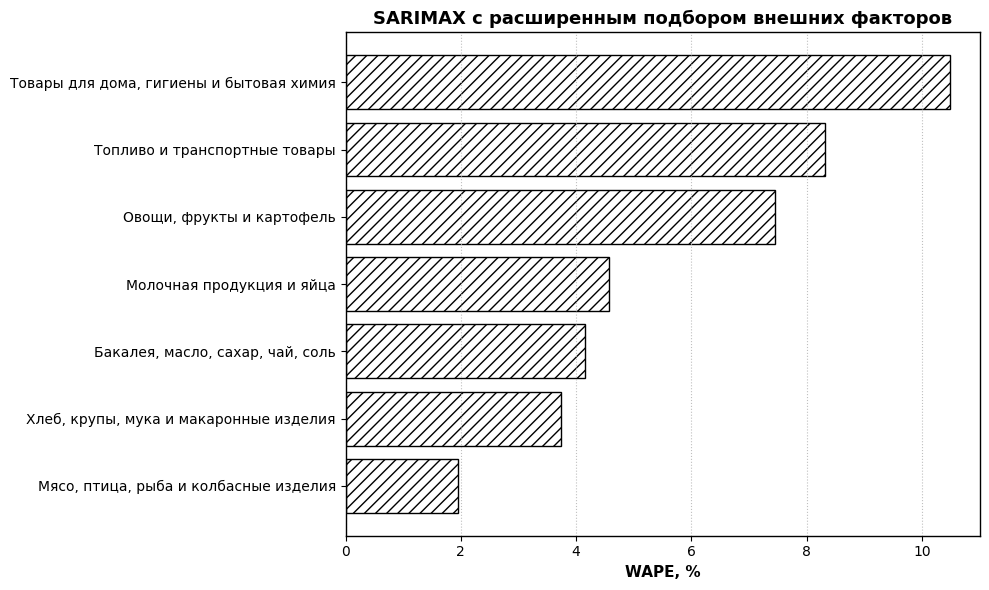

Сохранено:
/home/senya/projects/diplom/dataset/sarimax_aggressive_exog_selection/sarimax_aggressive_exog_forecasts.csv
/home/senya/projects/diplom/dataset/sarimax_aggressive_exog_selection/sarimax_aggressive_exog_product_summary.csv
/home/senya/projects/diplom/dataset/sarimax_aggressive_exog_selection/sarimax_aggressive_exog_category_summary.csv
/home/senya/projects/diplom/dataset/sarimax_aggressive_exog_selection/sarimax_aggressive_exog_selected_features.csv
/home/senya/projects/diplom/dataset/sarimax_aggressive_exog_selection/sarimax_aggressive_exog_vs_previous.csv
/home/senya/projects/diplom/dataset/sarimax_aggressive_exog_selection/sarimax_aggressive_exog_category_wape_bw.png


In [29]:
from pathlib import Path

import warnings

import itertools

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

data_dir = Path.cwd() / "dataset"

data_file = data_dir / "demand_training_with_physical_volume.csv"

if not data_file.exists():

    data_file = data_dir / "demand_primary_training_minimal_with_ppi.csv"

if not data_file.exists():

    data_file = data_dir / "demand_primary_training_minimal.csv"

out_dir = data_dir / "sarimax_aggressive_exog_selection"

out_dir.mkdir(parents=True, exist_ok=True)

forecast_file = out_dir / "sarimax_aggressive_exog_forecasts.csv"

OUT_PRODUCT_SUMMARY = out_dir / "sarimax_aggressive_exog_product_summary.csv"

OUT_CATEGORY_SUMMARY = out_dir / "sarimax_aggressive_exog_category_summary.csv"

OUT_FEATURES = out_dir / "sarimax_aggressive_exog_selected_features.csv"

OUT_COMPARISON = out_dir / "sarimax_aggressive_exog_vs_previous.csv"

OUT_PLOT = out_dir / "sarimax_aggressive_exog_category_wape_bw.png"

print("Датасет:", data_file)

print("Папка вывода:", out_dir)

target = "target_demand_index"

drop_outliers = True

outlier_products = ["Молочные напитки"]

min_train = 12

max_cv = 3

horizon = 4

MAX_SELECTED_FEATURES = 3

MIN_IMPROVEMENT_PP = 0.15

ORDER_GRID = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2),
]

SEASONAL_ORDER_GRID = [
    (0, 0, 0, 4),
    (1, 0, 0, 4),
    (0, 0, 1, 4),
    (1, 0, 1, 4),
]

raw_factors = [
    "consumer_price_index",
    "income_index",
    "stock_days_mean",
    "stock_value_mean_thousand_rub",
    "ppi_product_index",
    "ppi_product_index_quarter_mean",
    "ppi_quarterly_index",
    "physical_volume_index",
]


def calc_rmse(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=float)

    y_pred = np.asarray(y_pred, dtype=float)

    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def calc_mape(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=float)

    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0

    if mask.sum() == 0:

        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def calc_wape(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=float)

    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:

        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator * 100


def period_end_date(period):

    return period.to_timestamp(how="end").normalize()


df = pd.read_csv(data_file)

df = df.rename(
    columns={
        "sales_product_code": "product_code",
        "sales_product_name": "product_name",
        "product_group_name": "group_name",
        "physical_volume_cumulative_yoy_index": "physical_volume_index",
    }
)

df["period_end"] = pd.to_datetime(df["period_end"])

df["period"] = df["period_end"].dt.to_period("Q")

df["year"] = df["period"].dt.year

df["quarter"] = df["period"].dt.quarter

df = df.sort_values(["product_name", "period"]).copy()

if drop_outliers:

    df = df[~df["product_name"].isin(outlier_products)].copy()

required_cols = [
    "product_name",
    "period",
    "period_end",
    "year",
    "quarter",
    target,
]

for col in required_cols:

    if col not in df.columns:

        raise ValueError(f"Нет колонки: {col}")

raw_cols = [col for col in raw_factors if col in df.columns]

print("Строк:", len(df))

print("Товаров:", df["product_name"].nunique())

print("Период:", df["period"].min(), "—", df["period"].max())

print("Доступные внешние факторы:")

for col in raw_cols:

    print("-", col)


def add_strict_lagged_exog_features(data, raw_exog_cols):
    """
    Создает факторы, которые можно использовать при прогнозе года вперед.
    Для периода t используются только значения t-4, t-8 и более старые.
    """

    data = data.sort_values(["product_name", "period"]).copy()

    for col in raw_exog_cols:

        if col not in data.columns:

            continue

        data[f"group_{col}_mean"] = (
            data.groupby(["group_code", "period"])[col].transform("mean")
            if "group_code" in data.columns
            else data.groupby(["group_name", "period"])[col].transform("mean")
        )

        data[f"market_{col}_mean"] = data.groupby("period")[col].transform("mean")

    new_cols = []

    base_cols = []

    for col in raw_exog_cols:

        base_cols.append(col)

        base_cols.append(f"group_{col}_mean")

        base_cols.append(f"market_{col}_mean")

    base_cols = [col for col in base_cols if col in data.columns]

    for col in base_cols:

        lag4 = f"{col}_lag4"

        lag8 = f"{col}_lag8"

        yoy = f"{col}_lag4_vs_lag8"

        yoy_pct = f"{col}_lag4_vs_lag8_pct"

        data[lag4] = data.groupby("product_name")[col].shift(4)

        data[lag8] = data.groupby("product_name")[col].shift(8)

        data[yoy] = data[lag4] - data[lag8]

        denominator = data[lag8].replace(0, np.nan)

        data[yoy_pct] = (data[lag4] / denominator - 1) * 100

        new_cols.extend([lag4, lag8, yoy, yoy_pct])

    for col in raw_exog_cols:

        product_lag4 = f"{col}_lag4"

        group_lag4 = f"group_{col}_mean_lag4"

        market_lag4 = f"market_{col}_mean_lag4"

        if product_lag4 in data.columns and group_lag4 in data.columns:

            diff_col = f"{col}_lag4_minus_group"

            ratio_col = f"{col}_lag4_div_group"

            data[diff_col] = data[product_lag4] - data[group_lag4]

            data[ratio_col] = data[product_lag4] / data[group_lag4].replace(0, np.nan)

            new_cols.extend([diff_col, ratio_col])

        if product_lag4 in data.columns and market_lag4 in data.columns:

            diff_col = f"{col}_lag4_minus_market"

            ratio_col = f"{col}_lag4_div_market"

            data[diff_col] = data[product_lag4] - data[market_lag4]

            data[ratio_col] = data[product_lag4] / data[market_lag4].replace(0, np.nan)

            new_cols.extend([diff_col, ratio_col])

    new_cols = list(dict.fromkeys([col for col in new_cols if col in data.columns]))

    return data, new_cols


df, GENERATED_EXOG_COLS = add_strict_lagged_exog_features(df, raw_cols)

print("Сгенерировано внешних признаков:", len(GENERATED_EXOG_COLS))

for col in GENERATED_EXOG_COLS[:50]:

    print("-", col)

if len(GENERATED_EXOG_COLS) > 50:

    print("...")


def existing(cols):

    return [col for col in cols if col in GENERATED_EXOG_COLS or col in df.columns]


PRICE_FEATURES = existing(
    [
        "consumer_price_index_lag4",
        "consumer_price_index_lag8",
        "consumer_price_index_lag4_vs_lag8",
        "consumer_price_index_lag4_vs_lag8_pct",
        "consumer_price_index_lag4_minus_group",
        "consumer_price_index_lag4_minus_market",
        "ppi_product_index_lag4",
        "ppi_product_index_lag8",
        "ppi_product_index_lag4_vs_lag8",
        "ppi_product_index_lag4_vs_lag8_pct",
        "ppi_quarterly_index_lag4",
        "ppi_quarterly_index_lag4_vs_lag8",
    ]
)

INCOME_FEATURES = existing(
    [
        "income_index_lag4",
        "income_index_lag8",
        "income_index_lag4_vs_lag8",
        "income_index_lag4_vs_lag8_pct",
        "income_index_lag4_minus_group",
        "income_index_lag4_minus_market",
    ]
)

STOCK_FEATURES = existing(
    [
        "stock_days_mean_lag4",
        "stock_days_mean_lag8",
        "stock_days_mean_lag4_vs_lag8",
        "stock_days_mean_lag4_vs_lag8_pct",
        "stock_value_mean_thousand_rub_lag4",
        "stock_value_mean_thousand_rub_lag8",
        "stock_value_mean_thousand_rub_lag4_vs_lag8",
        "stock_value_mean_thousand_rub_lag4_vs_lag8_pct",
        "stock_value_mean_thousand_rub_lag4_minus_group",
        "stock_value_mean_thousand_rub_lag4_minus_market",
    ]
)

PHYSICAL_FEATURES = existing(
    [
        "physical_volume_index_lag4",
        "physical_volume_index_lag8",
        "physical_volume_index_lag4_vs_lag8",
        "physical_volume_index_lag4_vs_lag8_pct",
        "physical_volume_index_lag4_minus_group",
        "physical_volume_index_lag4_minus_market",
    ]
)

RELATIVE_FEATURES = [
    col
    for col in GENERATED_EXOG_COLS
    if (
        "minus_group" in col
        or "minus_market" in col
        or "div_group" in col
        or "div_market" in col
    )
]

YOY_FEATURES = [col for col in GENERATED_EXOG_COLS if "vs_lag8" in col]

FEATURE_SETS = {
    "no_exog": [],
    "price": PRICE_FEATURES,
    "income": INCOME_FEATURES,
    "stock": STOCK_FEATURES,
    "physical": PHYSICAL_FEATURES,
    "price_stock": list(dict.fromkeys(PRICE_FEATURES + STOCK_FEATURES)),
    "price_income_stock": list(
        dict.fromkeys(PRICE_FEATURES + INCOME_FEATURES + STOCK_FEATURES)
    ),
    "relative": RELATIVE_FEATURES,
    "yoy_dynamics": YOY_FEATURES,
    "all_engineered": GENERATED_EXOG_COLS,
}

FEATURE_SETS = {
    name: cols
    for name, cols in FEATURE_SETS.items()
    if name == "no_exog" or len(cols) > 0
}

print("Наборы признаков:")

for name, cols in FEATURE_SETS.items():

    print(name, ":", len(cols))


def get_full_years(product_df):

    year_counts = (
        product_df[product_df[target].notna()].groupby("year")["quarter"].nunique()
    )

    return sorted(year_counts[year_counts == 4].index.tolist())


def get_cv_years(product_df):

    full_years = get_full_years(product_df)

    eligible_years = []

    for year in full_years:

        train_end = pd.Period(f"{year - 1}Q4", freq="Q")

        train_obs = product_df[
            (product_df["period"] <= train_end) & (product_df[target].notna())
        ]

        if len(train_obs) >= min_train:

            eligible_years.append(year)

    return eligible_years[-max_cv:]


product_cv_years = {}

for product_name, product_df in df.groupby("product_name"):

    cv_years = get_cv_years(product_df)

    if len(cv_years) > 0:

        product_cv_years[product_name] = cv_years

print("Товаров с rolling-backtest:", len(product_cv_years))

display(
    pd.DataFrame(
        [
            {
                "product_name": product_name,
                "cv_years": "; ".join(map(str, years)),
                "folds": len(years),
            }
            for product_name, years in product_cv_years.items()
        ]
    ).sort_values("product_name")
)


def filter_candidate_features(product_df, train_periods, candidate_cols):
    """
    Оставляет признаки с достаточным покрытием и вариативностью.
    """

    if not candidate_cols:

        return []

    product_indexed = product_df.set_index("period").sort_index()

    train_exog = product_indexed.reindex(train_periods)[candidate_cols].copy()

    kept = []

    for col in candidate_cols:

        coverage = train_exog[col].notna().mean()

        nunique = train_exog[col].nunique(dropna=True)

        if coverage >= 0.55 and nunique > 2:

            kept.append(col)

    return kept


def rank_features_by_correlation(
    product_df, train_periods, candidate_cols, max_features=8
):
    """
    Предварительно ранжирует признаки по корреляции с целевой переменной на train.
    Это не финальный выбор, а способ уменьшить перебор.
    """

    candidate_cols = filter_candidate_features(
        product_df, train_periods, candidate_cols
    )

    if not candidate_cols:

        return []

    product_indexed = product_df.set_index("period").sort_index()

    train_y = product_indexed.reindex(train_periods)[target].astype(float)

    train_x = product_indexed.reindex(train_periods)[candidate_cols].astype(float)

    rows = []

    for col in candidate_cols:

        temp = pd.DataFrame(
            {
                "y": train_y,
                "x": train_x[col],
            }
        ).dropna()

        if len(temp) < 8:

            continue

        corr = temp["y"].corr(temp["x"])

        if pd.notna(corr):

            rows.append(
                {
                    "feature": col,
                    "abs_corr": abs(corr),
                    "corr": corr,
                }
            )

    if len(rows) == 0:

        return []

    ranked = (
        pd.DataFrame(rows).sort_values("abs_corr", ascending=False).head(max_features)
    )

    return ranked["feature"].tolist()


def build_exog(product_df, train_periods, forecast_periods, exog_cols):
    """
    Строит стандартизированные train/future exog.
    scaler обучается только на train.
    """

    if not exog_cols:

        return None, None, []

    product_indexed = product_df.set_index("period").sort_index()

    train_exog = product_indexed.reindex(train_periods)[exog_cols].copy()

    future_exog = product_indexed.reindex(forecast_periods)[exog_cols].copy()

    train_exog = train_exog.astype(float).replace([np.inf, -np.inf], np.nan)

    future_exog = future_exog.astype(float).replace([np.inf, -np.inf], np.nan)

    medians = train_exog.median(numeric_only=True)

    train_exog = train_exog.ffill().bfill().fillna(medians).fillna(0)

    future_exog = future_exog.ffill().bfill().fillna(medians).fillna(0)

    scaler = StandardScaler()

    train_scaled = pd.DataFrame(
        scaler.fit_transform(train_exog),
        index=train_exog.index,
        columns=train_exog.columns,
    )

    future_scaled = pd.DataFrame(
        scaler.transform(future_exog),
        index=future_exog.index,
        columns=future_exog.columns,
    )

    return train_scaled, future_scaled, exog_cols


def fit_predict_sarimax(
    train_df, product_df, forecast_periods, order, seasonal_order, exog_cols
):

    y_train_raw = (
        train_df.set_index("period")[target].astype(float).dropna().sort_index()
    )

    train_periods = pd.period_range(
        y_train_raw.index.min(),
        y_train_raw.index.max(),
        freq="Q",
    )

    y_train = y_train_raw.reindex(train_periods)

    exog_train, exog_future, used_exog = build_exog(
        product_df=product_df,
        train_periods=train_periods,
        forecast_periods=forecast_periods,
        exog_cols=exog_cols,
    )

    model = SARIMAX(
        y_train,
        exog=exog_train if exog_train is not None and len(used_exog) > 0 else None,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    fitted = model.fit(disp=False, maxiter=200)

    pred = fitted.forecast(
        steps=len(forecast_periods),
        exog=exog_future if exog_future is not None and len(used_exog) > 0 else None,
    )

    return np.asarray(pred, dtype=float)


def evaluate_config(product_df, cv_years, order, seasonal_order, exog_cols):

    actual_all = []

    pred_all = []

    for year in cv_years:

        train_end = pd.Period(f"{year - 1}Q4", freq="Q")

        forecast_periods = pd.period_range(f"{year}Q1", f"{year}Q4", freq="Q")

        train_df = product_df[
            (product_df["period"] <= train_end) & (product_df[target].notna())
        ].copy()

        test_df = (
            product_df[product_df["period"].isin(forecast_periods)]
            .sort_values("period")
            .copy()
        )

        if len(train_df) < min_train or len(test_df) != 4:

            continue

        if test_df[target].isna().any():

            continue

        try:

            pred = fit_predict_sarimax(
                train_df=train_df,
                product_df=product_df,
                forecast_periods=forecast_periods,
                order=order,
                seasonal_order=seasonal_order,
                exog_cols=exog_cols,
            )

            actual_all.extend(test_df[target].values)

            pred_all.extend(pred)

        except Exception:

            continue

    if len(actual_all) == 0:

        return np.nan, np.nan, np.nan, np.nan

    return (
        np.mean(np.abs(np.asarray(actual_all) - np.asarray(pred_all))),
        calc_rmse(actual_all, pred_all),
        calc_mape(actual_all, pred_all),
        calc_wape(actual_all, pred_all),
    )


def find_best_order_for_features(product_df, cv_years, exog_cols):

    rows = []

    for order, seasonal_order in itertools.product(ORDER_GRID, SEASONAL_ORDER_GRID):

        mae, rmse, mape, wape = evaluate_config(
            product_df=product_df,
            cv_years=cv_years,
            order=order,
            seasonal_order=seasonal_order,
            exog_cols=exog_cols,
        )

        if pd.notna(wape):

            rows.append(
                {
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "MAE": mae,
                    "RMSE": rmse,
                    "MAPE_%": mape,
                    "WAPE_%": wape,
                }
            )

    if len(rows) == 0:

        return None

    return pd.DataFrame(rows).sort_values("WAPE_%").iloc[0].to_dict()


def select_features_greedy(product_df, cv_years):
    last_cv_year = max(cv_years)

    train_end_for_ranking = pd.Period(f"{last_cv_year - 1}Q4", freq="Q")

    train_data = product_df[
        (product_df["period"] <= train_end_for_ranking) & (product_df[target].notna())
    ]

    train_periods_for_ranking = pd.period_range(
        train_data["period"].min(), train_data["period"].max(), freq="Q"
    )

    base_best = find_best_order_for_features(
        product_df=product_df,
        cv_years=cv_years,
        exog_cols=[],
    )

    if base_best is None:

        return None

    best_features = []

    best_order = base_best["order"]

    best_seasonal_order = base_best["seasonal_order"]

    best_wape = base_best["WAPE_%"]

    selection_steps = [
        {
            "step": 0,
            "candidate_feature": None,
            "selected_features": "",
            "order": best_order,
            "seasonal_order": best_seasonal_order,
            "WAPE_%": best_wape,
            "accepted": True,
        }
    ]

    candidate_pool = []

    for set_name, cols in FEATURE_SETS.items():

        if set_name == "no_exog":

            continue

        ranked = rank_features_by_correlation(
            product_df=product_df,
            train_periods=train_periods_for_ranking,
            candidate_cols=cols,
            max_features=6,
        )

        for feature in ranked:

            candidate_pool.append(feature)

    candidate_pool = list(dict.fromkeys(candidate_pool))

    candidate_pool = candidate_pool[:18]

    for step in range(1, MAX_SELECTED_FEATURES + 1):

        step_candidates = []

        for feature in candidate_pool:

            if feature in best_features:

                continue

            trial_features = best_features + [feature]

            trial_best = find_best_order_for_features(
                product_df=product_df,
                cv_years=cv_years,
                exog_cols=trial_features,
            )

            if trial_best is None:

                continue

            step_candidates.append(
                {
                    "feature": feature,
                    "features": trial_features,
                    "order": trial_best["order"],
                    "seasonal_order": trial_best["seasonal_order"],
                    "WAPE_%": trial_best["WAPE_%"],
                    "MAE": trial_best["MAE"],
                    "RMSE": trial_best["RMSE"],
                    "MAPE_%": trial_best["MAPE_%"],
                }
            )

        if len(step_candidates) == 0:

            break

        best_candidate = (
            pd.DataFrame(step_candidates).sort_values("WAPE_%").iloc[0].to_dict()
        )

        improvement = best_wape - best_candidate["WAPE_%"]

        accepted = improvement >= MIN_IMPROVEMENT_PP

        selection_steps.append(
            {
                "step": step,
                "candidate_feature": best_candidate["feature"],
                "selected_features": "; ".join(best_candidate["features"]),
                "order": best_candidate["order"],
                "seasonal_order": best_candidate["seasonal_order"],
                "WAPE_%": best_candidate["WAPE_%"],
                "improvement_pp": improvement,
                "accepted": accepted,
            }
        )

        if not accepted:

            break

        best_features = best_candidate["features"]

        best_order = best_candidate["order"]

        best_seasonal_order = best_candidate["seasonal_order"]

        best_wape = best_candidate["WAPE_%"]

    final_mae, final_rmse, final_mape, final_wape = evaluate_config(
        product_df=product_df,
        cv_years=cv_years,
        order=best_order,
        seasonal_order=best_seasonal_order,
        exog_cols=best_features,
    )

    return {
        "selected_features": best_features,
        "order": best_order,
        "seasonal_order": best_seasonal_order,
        "MAE": final_mae,
        "RMSE": final_rmse,
        "MAPE_%": final_mape,
        "WAPE_%": final_wape,
        "base_WAPE_%": base_best["WAPE_%"],
        "selection_steps": pd.DataFrame(selection_steps),
    }


forecast_rows = []

product_summary_rows = []

feature_rows = []

selection_steps_all = []

for product_name, product_df in df.groupby("product_name"):

    product_df = product_df.sort_values("period").copy()

    if product_name not in product_cv_years:

        continue

    cv_years = product_cv_years[product_name]

    product_code = (
        product_df["product_code"].dropna().iloc[0]
        if "product_code" in product_df.columns
        and product_df["product_code"].notna().any()
        else None
    )

    group_code = (
        product_df["group_code"].dropna().iloc[0]
        if "group_code" in product_df.columns and product_df["group_code"].notna().any()
        else None
    )

    group_name = (
        product_df["group_name"].dropna().iloc[0]
        if "group_name" in product_df.columns and product_df["group_name"].notna().any()
        else None
    )

    print("=" * 100)

    print("Товар:", product_name)

    print("CV годы:", cv_years)

    best = select_features_greedy(product_df, cv_years)

    if best is None:

        print("Не удалось подобрать модель:", product_name)

        continue

    selected_features = best["selected_features"]

    order = best["order"]

    seasonal_order = best["seasonal_order"]

    print("Лучший WAPE:", round(best["WAPE_%"], 2))

    print("База WAPE:", round(best["base_WAPE_%"], 2))

    print("Признаки:", selected_features)

    print("order:", order)

    print("seasonal_order:", seasonal_order)

    steps = best["selection_steps"].copy()

    steps["product_name"] = product_name

    selection_steps_all.append(steps)

    product_summary_rows.append(
        {
            "model": "sarimax_aggressive_exog",
            "product_code": product_code,
            "product_name": product_name,
            "group_code": group_code,
            "group_name": group_name,
            "cv_years": "; ".join(map(str, cv_years)),
            "observations_count": len(cv_years) * 4,
            "selected_features": "; ".join(selected_features),
            "features_count": len(selected_features),
            "order": str(order),
            "seasonal_order": str(seasonal_order),
            "base_WAPE_%": best["base_WAPE_%"],
            "MAE": best["MAE"],
            "RMSE": best["RMSE"],
            "MAPE_%": best["MAPE_%"],
            "WAPE_%": best["WAPE_%"],
            "improvement_vs_no_exog_pp": best["base_WAPE_%"] - best["WAPE_%"],
        }
    )

    for feature in selected_features:

        feature_rows.append(
            {
                "product_code": product_code,
                "product_name": product_name,
                "group_code": group_code,
                "group_name": group_name,
                "feature": feature,
            }
        )

    for year in cv_years:

        train_end = pd.Period(f"{year - 1}Q4", freq="Q")

        forecast_periods = pd.period_range(f"{year}Q1", f"{year}Q4", freq="Q")

        train_df = product_df[
            (product_df["period"] <= train_end) & (product_df[target].notna())
        ].copy()

        test_df = (
            product_df[product_df["period"].isin(forecast_periods)]
            .sort_values("period")
            .copy()
        )

        if len(train_df) < min_train or len(test_df) != 4:

            continue

        if test_df[target].isna().any():

            continue

        try:

            pred = fit_predict_sarimax(
                train_df=train_df,
                product_df=product_df,
                forecast_periods=forecast_periods,
                order=order,
                seasonal_order=seasonal_order,
                exog_cols=selected_features,
            )

            for i, period in enumerate(forecast_periods):

                forecast_rows.append(
                    {
                        "model": "sarimax_aggressive_exog",
                        "product_code": product_code,
                        "product_name": product_name,
                        "group_code": group_code,
                        "group_name": group_name,
                        "cv_year": year,
                        "period": str(period),
                        "period_end": period_end_date(period),
                        "train_start": str(train_df["period"].min()),
                        "train_end": str(train_end),
                        "actual_target_demand_index": test_df[target].iloc[i],
                        "forecast_target_demand_index": pred[i],
                        "selected_features": "; ".join(selected_features),
                        "order": str(order),
                        "seasonal_order": str(seasonal_order),
                    }
                )

        except Exception as e:

            print("Forecast error:", product_name, year, e)

forecasts = pd.DataFrame(forecast_rows)

if forecasts.empty:

    raise ValueError("Не построено ни одного прогноза.")

forecasts["error"] = (
    forecasts["forecast_target_demand_index"] - forecasts["actual_target_demand_index"]
)

forecasts["abs_error"] = forecasts["error"].abs()

forecasts["ape_%"] = (
    forecasts["abs_error"] / forecasts["actual_target_demand_index"].abs() * 100
)

product_summary = pd.DataFrame(product_summary_rows)

features_selected = pd.DataFrame(feature_rows)

selection_steps = (
    pd.concat(selection_steps_all, ignore_index=True)
    if len(selection_steps_all) > 0
    else pd.DataFrame()
)

category_rows = []

for (group_code, group_name), temp in forecasts.groupby(
    ["group_code", "group_name"], dropna=False
):

    y_true = temp["actual_target_demand_index"].values

    y_pred = temp["forecast_target_demand_index"].values

    category_rows.append(
        {
            "model": "sarimax_aggressive_exog",
            "group_code": group_code,
            "group_name": group_name,
            "products_count": temp["product_name"].nunique(),
            "observations_count": len(temp),
            "cv_years": "; ".join(sorted(temp["cv_year"].astype(str).unique())),
            "MAE": np.mean(np.abs(y_true - y_pred)),
            "RMSE": calc_rmse(y_true, y_pred),
            "MAPE_%": calc_mape(y_true, y_pred),
            "WAPE_%": calc_wape(y_true, y_pred),
        }
    )

category_summary = (
    pd.DataFrame(category_rows).sort_values("WAPE_%").reset_index(drop=True)
)

forecasts.to_csv(forecast_file, index=False, encoding="utf-8-sig")

product_summary.to_csv(OUT_PRODUCT_SUMMARY, index=False, encoding="utf-8-sig")

category_summary.to_csv(OUT_CATEGORY_SUMMARY, index=False, encoding="utf-8-sig")

features_selected.to_csv(OUT_FEATURES, index=False, encoding="utf-8-sig")

selection_steps.to_csv(
    out_dir / "sarimax_aggressive_exog_selection_steps.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Итог по категориям:")

display(category_summary.round(2))

print("Итог по товарам:")

display(product_summary.sort_values("WAPE_%").round(2))

print("Выбранные признаки:")

display(features_selected.head(50))

PREVIOUS_CANDIDATES = [
    data_dir / "individual_prophet_lgbm_selection" / "best_all_models_by_category.csv",
    data_dir / "sarimax_category_summary_clean_no_anomaly.csv",
]

previous_path = None

for path in PREVIOUS_CANDIDATES:

    if path.exists():

        previous_path = path

        break

if previous_path is not None:

    previous = pd.read_csv(previous_path)

    if previous["group_name"].duplicated().any():

        previous = (
            previous.sort_values(["group_name", "WAPE_%"])
            .groupby("group_name", as_index=False)
            .head(1)
            .reset_index(drop=True)
        )

    compare = (
        previous[["group_name", "model", "MAE", "RMSE", "MAPE_%", "WAPE_%"]]
        .rename(
            columns={
                "model": "previous_model",
                "MAE": "previous_MAE",
                "RMSE": "previous_RMSE",
                "MAPE_%": "previous_MAPE_%",
                "WAPE_%": "previous_WAPE_%",
            }
        )
        .merge(
            category_summary[
                ["group_name", "model", "MAE", "RMSE", "MAPE_%", "WAPE_%"]
            ].rename(
                columns={
                    "model": "new_model",
                    "MAE": "new_MAE",
                    "RMSE": "new_RMSE",
                    "MAPE_%": "new_MAPE_%",
                    "WAPE_%": "new_WAPE_%",
                }
            ),
            on="group_name",
            how="outer",
        )
    )

    compare["WAPE_improvement_pp"] = compare["previous_WAPE_%"] - compare["new_WAPE_%"]

    compare["MAPE_improvement_pp"] = compare["previous_MAPE_%"] - compare["new_MAPE_%"]

    compare["MAE_improvement"] = compare["previous_MAE"] - compare["new_MAE"]

    compare["RMSE_improvement"] = compare["previous_RMSE"] - compare["new_RMSE"]

    compare = compare.sort_values("new_WAPE_%")

    compare.to_csv(OUT_COMPARISON, index=False, encoding="utf-8-sig")

    print("Сравнение с предыдущей финальной таблицей:")

    display(compare.round(2))

else:

    print("Предыдущая финальная таблица не найдена.")

doc_table = category_summary[
    [
        "model",
        "group_code",
        "group_name",
        "products_count",
        "observations_count",
        "cv_years",
        "MAE",
        "RMSE",
        "MAPE_%",
        "WAPE_%",
    ]
].rename(
    columns={
        "model": "Модель",
        "group_code": "Код группы",
        "group_name": "Группа товаров",
        "products_count": "Кол-во товаров",
        "observations_count": "Кол-во наблюдений",
        "cv_years": "Проверочные годы",
        "MAPE_%": "MAPE, %",
        "WAPE_%": "WAPE, %",
    }
)

for col in doc_table.columns:

    if pd.api.types.is_numeric_dtype(doc_table[col]):

        doc_table[col] = doc_table[col].round(2)

print("=== Таблица для Google Sheets ===")

print(doc_table.to_csv(sep="\t", index=False, decimal=","))

plot_df = category_summary.sort_values("WAPE_%", ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["group_name"],
    plot_df["WAPE_%"],
    facecolor="white",
    edgecolor="black",
    hatch="///",
    linewidth=1.0,
)

ax.set_xlabel("WAPE, %", fontsize=11, fontweight="bold")

ax.set_title(
    "SARIMAX с расширенным подбором внешних факторов", fontsize=13, fontweight="bold"
)

ax.grid(True, axis="x", linestyle=":", linewidth=0.8, alpha=0.8)

for spine in ax.spines.values():

    spine.set_color("black")

    spine.set_linewidth(1.0)

plt.tight_layout()

plt.savefig(OUT_PLOT, dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

print("Сохранено:")

print(forecast_file)

print(OUT_PRODUCT_SUMMARY)

print(OUT_CATEGORY_SUMMARY)

print(OUT_FEATURES)

print(OUT_COMPARISON)

print(OUT_PLOT)

<a id="block-05-factor-analysis"></a>

## Блок 5. Интерпретация выбранных факторов

Блок группирует технические признаки в экономические факторы и строит диаграмму частоты их выбора в итоговых моделях.

,factor,products_count
2,Запасы в рублях,1
4,Физический объем продаж,2
1,Запасы в днях,5
3,Потребительские цены,8
0,Доходы населения,13


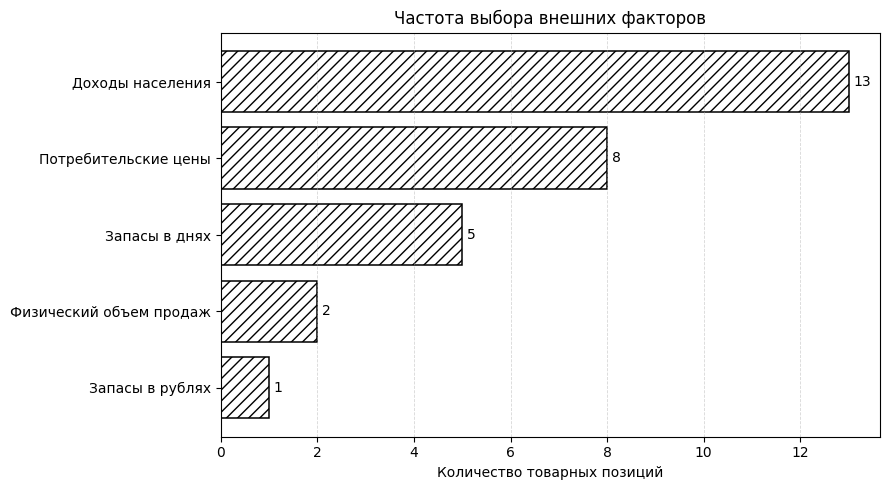

In [31]:
from pathlib import Path

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

result_dir = data_dir / "sarimax_aggressive_exog_selection"

product_file = result_dir / "sarimax_aggressive_exog_product_summary.csv"

plot_dir = Path.cwd() / "plots" / "factor_analysis"

plot_dir.mkdir(parents=True, exist_ok=True)

products = pd.read_csv(product_file)

products["selected_features"] = products["selected_features"].fillna("")


def split_features(value):

    return [item.strip() for item in str(value).split(";") if item.strip()]


def factor_name(name):

    text = str(name).lower()

    if text == "":

        return "Без внешних факторов"

    if "consumer_price" in text:

        return "Потребительские цены"

    if "ppi" in text:

        return "Цены производителей"

    if "income" in text:

        return "Доходы населения"

    if "stock_days" in text:

        return "Запасы в днях"

    if "stock_value" in text:

        return "Запасы в рублях"

    if "physical_volume" in text:

        return "Физический объем продаж"

    return "Прочие факторы"


rows = []

for _, row in products.iterrows():

    factors = split_features(row.get("selected_features", ""))

    if not factors:

        rows.append(
            {
                "group_name": row.get("group_name"),
                "product_name": row.get("product_name"),
                "factor": "Без внешних факторов",
                "selected": 1,
            }
        )

    else:

        for feature in factors:

            rows.append(
                {
                    "group_name": row.get("group_name"),
                    "product_name": row.get("product_name"),
                    "factor": factor_name(feature),
                    "selected": 1,
                }
            )

factor_rows = pd.DataFrame(rows)

factor_freq = (
    factor_rows.drop_duplicates(["product_name", "factor"])
    .groupby("factor", as_index=False)
    .agg(products_count=("product_name", "nunique"))
    .sort_values("products_count", ascending=True)
)

display(factor_freq)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    factor_freq["factor"],
    factor_freq["products_count"],
    facecolor="white",
    edgecolor="black",
    hatch="///",
    linewidth=1.1,
)

for bar, value in zip(bars, factor_freq["products_count"]):

    ax.text(value + 0.1, bar.get_y() + bar.get_height() / 2, str(value), va="center")

ax.set_title("Частота выбора внешних факторов")

ax.set_xlabel("Количество товарных позиций")

ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.5)

fig.tight_layout()

fig.savefig(
    plot_dir / "factor_frequency_bw.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

## Блок 6. Прогноз до начала 2027 года

In [32]:
from pathlib import Path

import ast

import warnings

import numpy as np

import pandas as pd

from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

result_dir = data_dir / "sarimax_aggressive_exog_selection"

product_file = result_dir / "sarimax_aggressive_exog_product_summary.csv"

future_file = result_dir / "sarimax_future_forecast_to_2027Q1_by_product.csv"

future_errors_file = result_dir / "sarimax_future_forecast_errors.csv"

forecast_end = pd.Period("2027Q1", freq="Q")


def period_end(period):

    return period.to_timestamp(how="end").normalize()


def parse_tuple(value):

    if pd.isna(value):

        return None

    if isinstance(value, tuple):

        return value

    return tuple(ast.literal_eval(str(value)))


def parse_features(value):

    if pd.isna(value) or str(value).strip() == "":

        return []

    return [item.strip() for item in str(value).split(";") if item.strip()]


def parse_last_year(value):

    if pd.isna(value) or str(value).strip() == "":

        return None

    years = []

    for item in str(value).replace(",", ";").split(";"):

        item = item.strip()

        if item.isdigit():

            years.append(int(item))

    return max(years) if years else None


def load_data():

    data = pd.read_csv(data_file)

    data = data.rename(
        columns={
            "sales_product_code": "product_code",
            "sales_product_name": "product_name",
            "product_group_name": "group_name",
            "physical_volume_cumulative_yoy_index": "physical_volume_index",
        }
    )

    data["period_end"] = pd.to_datetime(data["period_end"])

    data["period"] = data["period_end"].dt.to_period("Q")

    data["year"] = data["period"].dt.year

    data["quarter"] = data["period"].dt.quarter

    data = data.sort_values(["product_name", "period"]).copy()

    if drop_outliers:

        data = data[~data["product_name"].isin(outlier_products)].copy()

    return data


def collapse_rows(data):

    num_cols = data.select_dtypes(include=["number"]).columns.tolist()
    key_cols = ["product_name", "period"]
    other_cols = [
        col for col in data.columns if col not in num_cols and col not in key_cols
    ]
    agg = {col: "mean" for col in num_cols}
    agg.update({col: "last" for col in other_cols})

    return data.sort_values(key_cols).groupby(key_cols, as_index=False).agg(agg)


def add_future_rows(data, product_tbl, end_period):

    rows = []

    for _, model_row in product_tbl.iterrows():
        name = model_row["product_name"]
        part = data[data["product_name"] == name].sort_values("period")
        
        if part.empty:
            continue

        last_year = parse_last_year(model_row.get("cv_years"))

        start = (
            pd.Period(f"{last_year}Q4", freq="Q") + 1
            if last_year
            else part[target].dropna().index.max()
        )

        template = part.iloc[-1].copy()

        for period in pd.period_range(start, end_period, freq="Q"):
            item = template.copy()
            item["period"] = period
            item["period_end"] = period_end(period)
            item["year"] = period.year
            item["quarter"] = period.quarter
            item[target] = np.nan
            rows.append(item)

    if not rows:
        return data.copy()

    return pd.concat([data, pd.DataFrame(rows)], ignore_index=True).sort_values(
        ["product_name", "period"]
    )


def fill_future_factors(data, cols):

    data = data.sort_values(["product_name", "period"]).copy()

    for name, part in data.groupby("product_name"):
        idx = part.index.tolist()

        for col in cols:
            if col not in data.columns:
                continue

            series = (
                data.loc[idx, ["period", col]]
                .groupby("period")[col]
                .last()
                .sort_index()
            )

            for row_id in idx:
                period = data.at[row_id, "period"]
                
                if pd.notna(data.at[row_id, col]):
                    continue

                prev = period - 4

                value = (
                    series.loc[prev]
                    if prev in series.index and pd.notna(series.loc[prev])
                    else np.nan
                )

                if pd.isna(value):
                    known = series.dropna()
                    value = known.iloc[-1] if len(known) else np.nan

                data.at[row_id, col] = value

                if pd.notna(value):
                    series.loc[period] = value
                    series = series.sort_index()

    return data


def add_factor_lags(data, cols):

    data = data.sort_values(["product_name", "period"]).copy()

    for col in cols:

        if col not in data.columns:

            continue

        data[f"group_{col}_mean"] = data.groupby(["group_name", "period"])[
            col
        ].transform("mean")

        data[f"market_{col}_mean"] = data.groupby("period")[col].transform("mean")

    base = []

    for col in cols:

        base.extend([col, f"group_{col}_mean", f"market_{col}_mean"])

    base = [col for col in base if col in data.columns]

    for col in base:

        data[f"{col}_lag4"] = data.groupby("product_name")[col].shift(4)

        data[f"{col}_lag8"] = data.groupby("product_name")[col].shift(8)

        data[f"{col}_lag4_vs_lag8"] = data[f"{col}_lag4"] - data[f"{col}_lag8"]

        data[f"{col}_lag4_vs_lag8_pct"] = (
            data[f"{col}_lag4"] / data[f"{col}_lag8"].replace(0, np.nan) - 1
        ) * 100

    for col in cols:

        p = f"{col}_lag4"

        g = f"group_{col}_mean_lag4"

        m = f"market_{col}_mean_lag4"

        if p in data.columns and g in data.columns:

            data[f"{col}_lag4_minus_group"] = data[p] - data[g]

            data[f"{col}_lag4_div_group"] = data[p] / data[g].replace(0, np.nan)

        if p in data.columns and m in data.columns:

            data[f"{col}_lag4_minus_market"] = data[p] - data[m]

            data[f"{col}_lag4_div_market"] = data[p] / data[m].replace(0, np.nan)

    return data


def prepare_exog(product_df, train_periods, future_periods, cols):

    cols = [col for col in cols if col in product_df.columns]

    if not cols:

        return None, None, []

    indexed = product_df.sort_values("period").groupby("period").last().sort_index()

    x_train = (
        indexed.reindex(train_periods)[cols]
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
    )

    x_future = (
        indexed.reindex(future_periods)[cols]
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
    )

    med = x_train.median(numeric_only=True)

    x_train = x_train.ffill().bfill().fillna(med).fillna(0)

    x_future = x_future.ffill().bfill().fillna(med).fillna(0)

    scaler = StandardScaler()

    x_train = pd.DataFrame(
        scaler.fit_transform(x_train), index=x_train.index, columns=x_train.columns
    )

    x_future = pd.DataFrame(
        scaler.transform(x_future), index=x_future.index, columns=x_future.columns
    )

    return x_train, x_future, cols


def forecast_product(train_df, product_df, future_periods, order, seasonal_order, cols):

    y = (
        train_df.sort_values("period")
        .groupby("period")[target]
        .mean()
        .astype(float)
        .dropna()
        .sort_index()
    )

    train_periods = pd.period_range(y.index.min(), y.index.max(), freq="Q")

    y = y.reindex(train_periods)

    x_train, x_future, used_cols = prepare_exog(
        product_df, train_periods, future_periods, cols
    )

    model = SARIMAX(
        y,
        exog=x_train if x_train is not None and used_cols else None,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    fitted = model.fit(disp=False, maxiter=200)

    res = fitted.get_forecast(
        steps=len(future_periods),
        exog=x_future if x_future is not None and used_cols else None,
    )

    pred = np.asarray(res.predicted_mean, dtype=float)

    ci = res.conf_int(alpha=0.05)

    return (
        pred,
        np.asarray(ci.iloc[:, 0], dtype=float),
        np.asarray(ci.iloc[:, 1], dtype=float),
        used_cols,
    )


product_tbl = pd.read_csv(product_file)

raw_cols = [col for col in raw_factors if col in load_data().columns]

data = collapse_rows(load_data())

data = collapse_rows(add_future_rows(data, product_tbl, forecast_end))

data = fill_future_factors(data, raw_cols)

data = add_factor_lags(data, raw_cols)

future_rows = []

error_rows = []

for _, model_row in product_tbl.iterrows():

    name = model_row["product_name"]

    part = data[data["product_name"] == name].sort_values("period").copy()

    if part.empty:

        error_rows.append({"product_name": name, "error": "Товар не найден"})

        continue

    last_year = parse_last_year(model_row.get("cv_years"))

    val_end = (
        pd.Period(f"{last_year}Q4", freq="Q")
        if last_year
        else part[part[target].notna()]["period"].max()
    )

    start = val_end + 1

    if start > forecast_end:

        continue

    future_periods = pd.period_range(start, forecast_end, freq="Q")

    train_df = part[(part["period"] <= val_end) & part[target].notna()].copy()

    order = parse_tuple(model_row["order"])

    seasonal_order = parse_tuple(model_row["seasonal_order"])

    cols = parse_features(model_row.get("selected_features"))

    try:

        pred, low, high, used_cols = forecast_product(
            train_df, part, future_periods, order, seasonal_order, cols
        )

        for i, period in enumerate(future_periods):

            future_rows.append(
                {
                    "model": "sarimax_exog",
                    "product_code": (
                        part["product_code"].dropna().iloc[0]
                        if "product_code" in part.columns
                        and part["product_code"].notna().any()
                        else None
                    ),
                    "product_name": name,
                    "group_name": (
                        part["group_name"].dropna().iloc[0]
                        if "group_name" in part.columns
                        and part["group_name"].notna().any()
                        else None
                    ),
                    "period": str(period),
                    "period_end": period_end(period),
                    "validation_end": str(val_end),
                    "forecast_target_demand_index": pred[i],
                    "forecast_lower_95": low[i],
                    "forecast_upper_95": high[i],
                    "order": str(order),
                    "seasonal_order": str(seasonal_order),
                    "selected_features": "; ".join(used_cols),
                }
            )

    except Exception as err:

        error_rows.append({"product_name": name, "error": str(err)})

future_forecast = (
    pd.DataFrame(future_rows)
    .sort_values(["group_name", "product_name", "period"])
    .reset_index(drop=True)
)

future_errors = pd.DataFrame(error_rows)

future_forecast.to_csv(future_file, index=False, encoding="utf-8-sig")

future_errors.to_csv(future_errors_file, index=False, encoding="utf-8-sig")

display(future_forecast.round(2))

if not future_errors.empty:

    display(future_errors)

,model,product_code,product_name,group_name,period,period_end,validation_end,forecast_target_demand_index,forecast_lower_95,forecast_upper_95,order,seasonal_order,selected_features
0,sarimax_exog,S_маргариновая_продукция,Маргариновая продукция,"Бакалея, масло, сахар, чай, соль",2026Q1,2026-03-31,2025Q4,79.48,69.63,89.33,"(1, 1, 2)","(1, 0, 1, 4)",physical_volume_index_lag4; income_index_lag8
1,sarimax_exog,S_маргариновая_продукция,Маргариновая продукция,"Бакалея, масло, сахар, чай, соль",2026Q2,2026-06-30,2025Q4,79.18,69.34,89.03,"(1, 1, 2)","(1, 0, 1, 4)",physical_volume_index_lag4; income_index_lag8
2,sarimax_exog,S_маргариновая_продукция,Маргариновая продукция,"Бакалея, масло, сахар, чай, соль",2026Q3,2026-09-30,2025Q4,78.08,68.23,87.93,"(1, 1, 2)","(1, 0, 1, 4)",physical_volume_index_lag4; income_index_lag8
3,sarimax_exog,S_маргариновая_продукция,Маргариновая продукция,"Бакалея, масло, сахар, чай, соль",2026Q4,2026-12-31,2025Q4,105.43,95.58,115.28,"(1, 1, 2)","(1, 0, 1, 4)",physical_volume_index_lag4; income_index_lag8
4,sarimax_exog,S_маргариновая_продукция,Маргариновая продукция,"Бакалея, масло, сахар, чай, соль",2027Q1,2027-03-31,2025Q4,82.85,69.23,96.47,"(1, 1, 2)","(1, 0, 1, 4)",physical_volume_index_lag4; income_index_lag8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,sarimax_exog,S_мука,Мука,"Хлеб, крупы, мука и макаронные изделия",2026Q1,2026-03-31,2025Q4,99.92,88.80,111.03,"(1, 1, 2)","(1, 0, 0, 4)",income_index_lag4_vs_lag8_pct
130,sarimax_exog,S_мука,Мука,"Хлеб, крупы, мука и макаронные изделия",2026Q2,2026-06-30,2025Q4,95.85,84.15,107.55,"(1, 1, 2)","(1, 0, 0, 4)",income_index_lag4_vs_lag8_pct
131,sarimax_exog,S_мука,Мука,"Хлеб, крупы, мука и макаронные изделия",2026Q3,2026-09-30,2025Q4,102.87,91.13,114.61,"(1, 1, 2)","(1, 0, 0, 4)",income_index_lag4_vs_lag8_pct
132,sarimax_exog,S_мука,Мука,"Хлеб, крупы, мука и макаронные изделия",2026Q4,2026-12-31,2025Q4,118.71,106.97,130.45,"(1, 1, 2)","(1, 0, 0, 4)",income_index_lag4_vs_lag8_pct


## Блок 7. Графики итогового прогноза

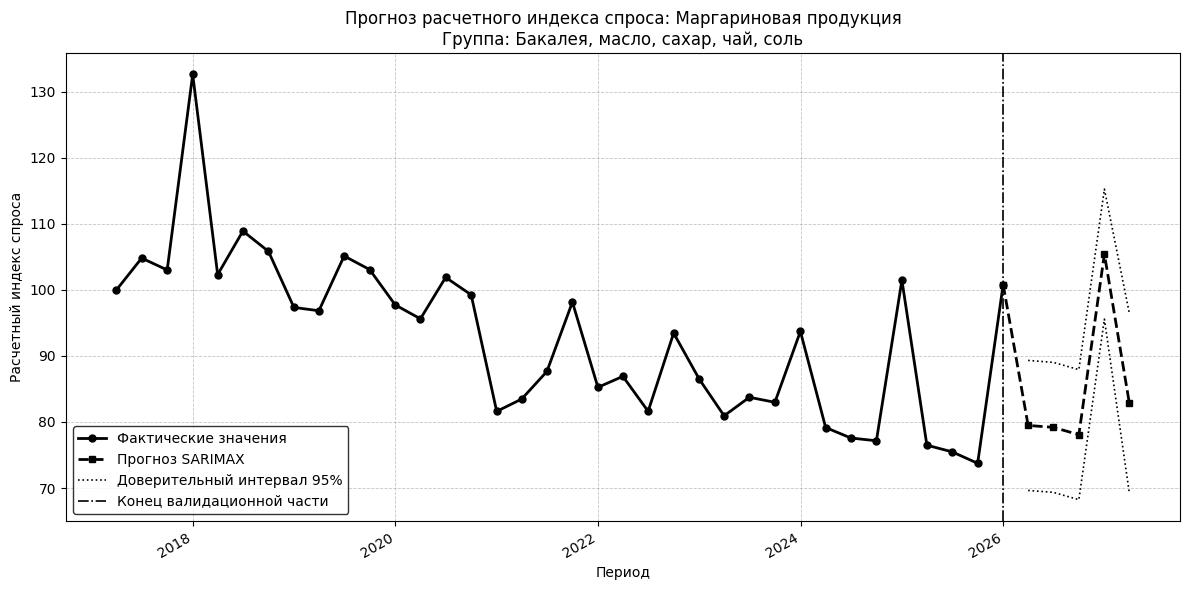

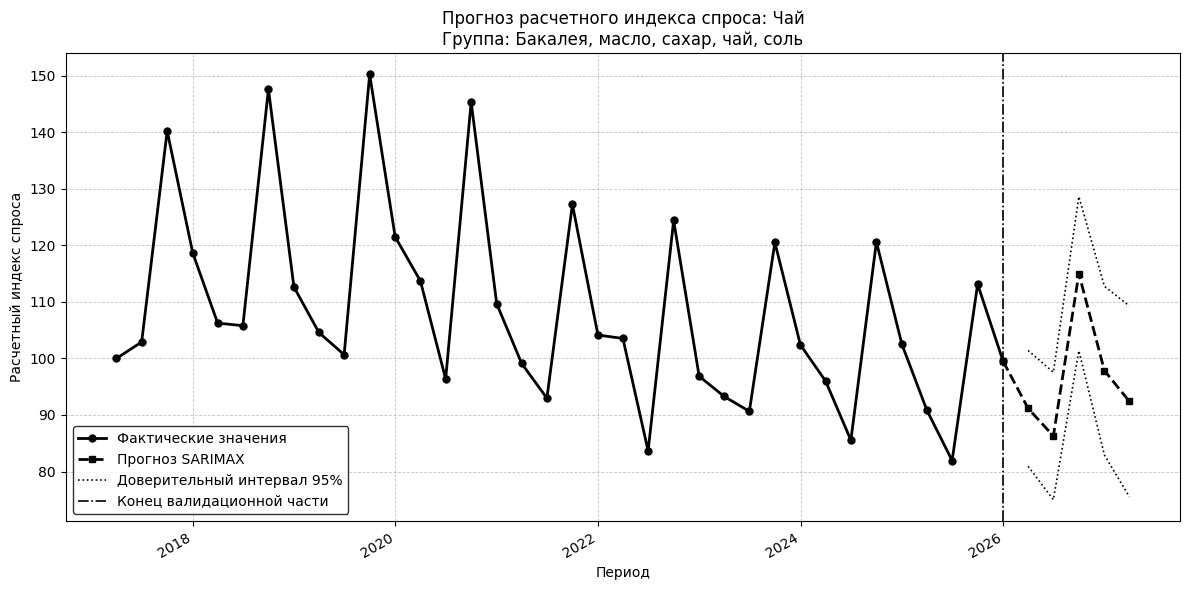

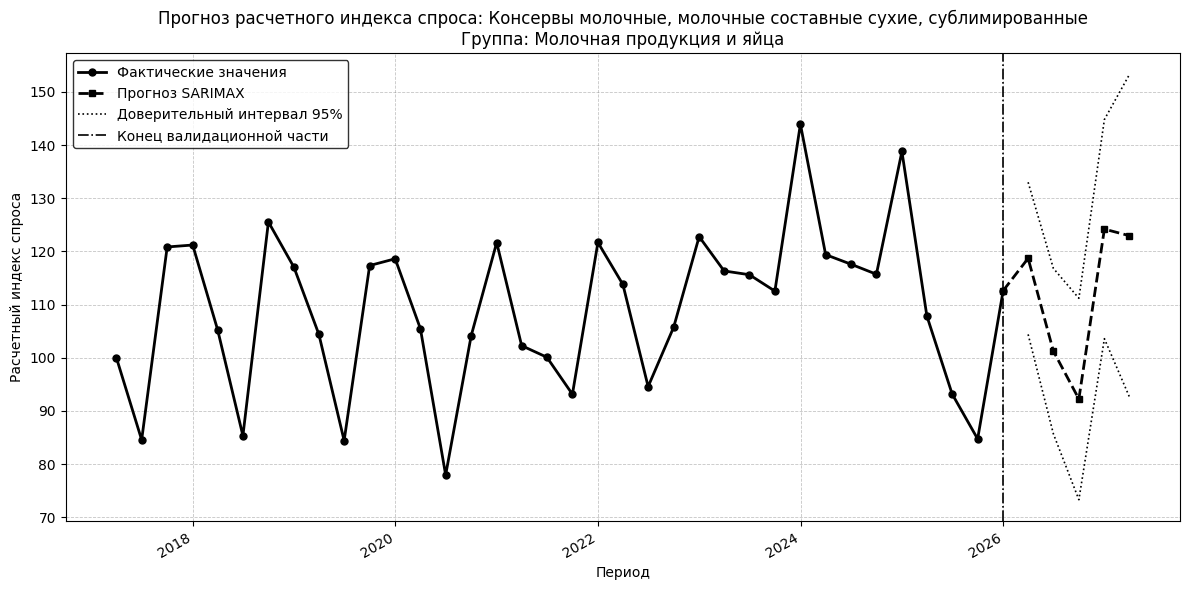

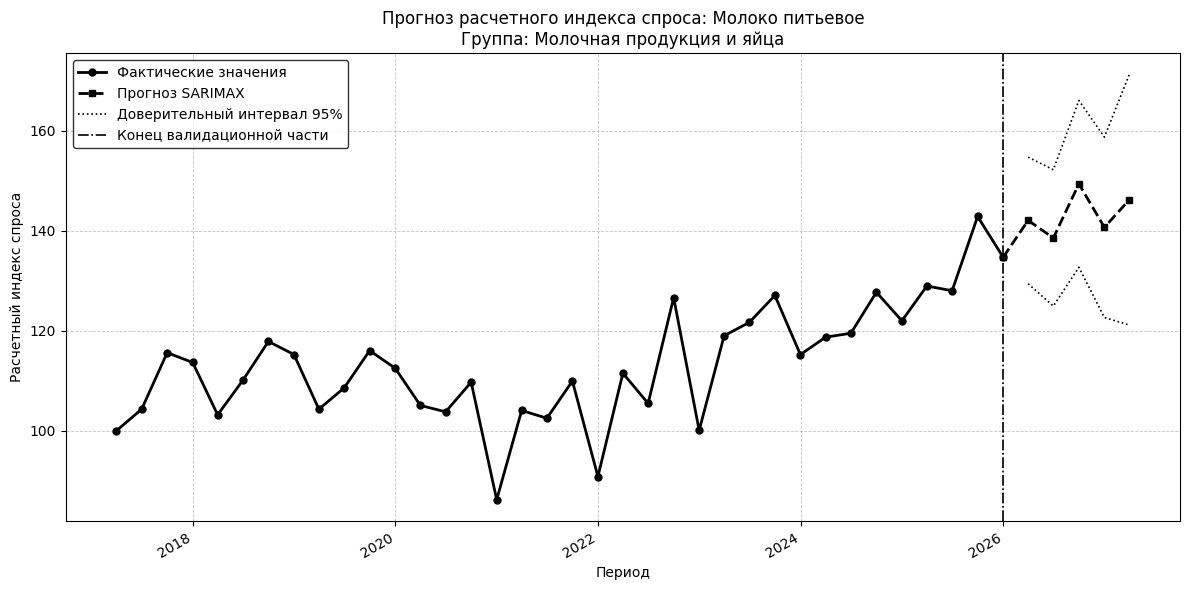

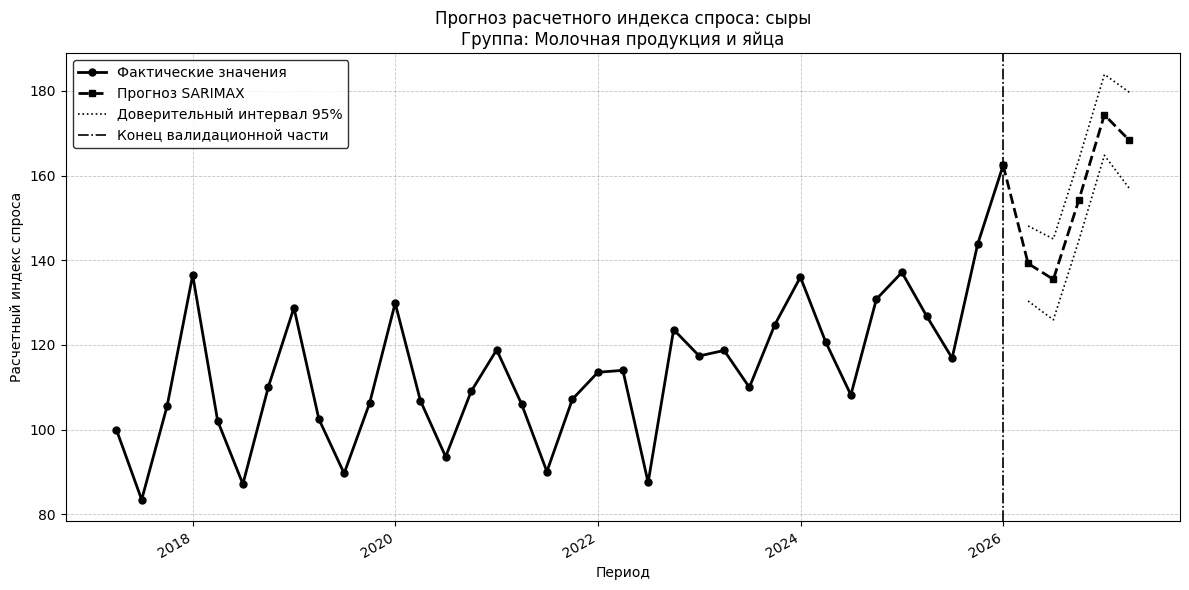

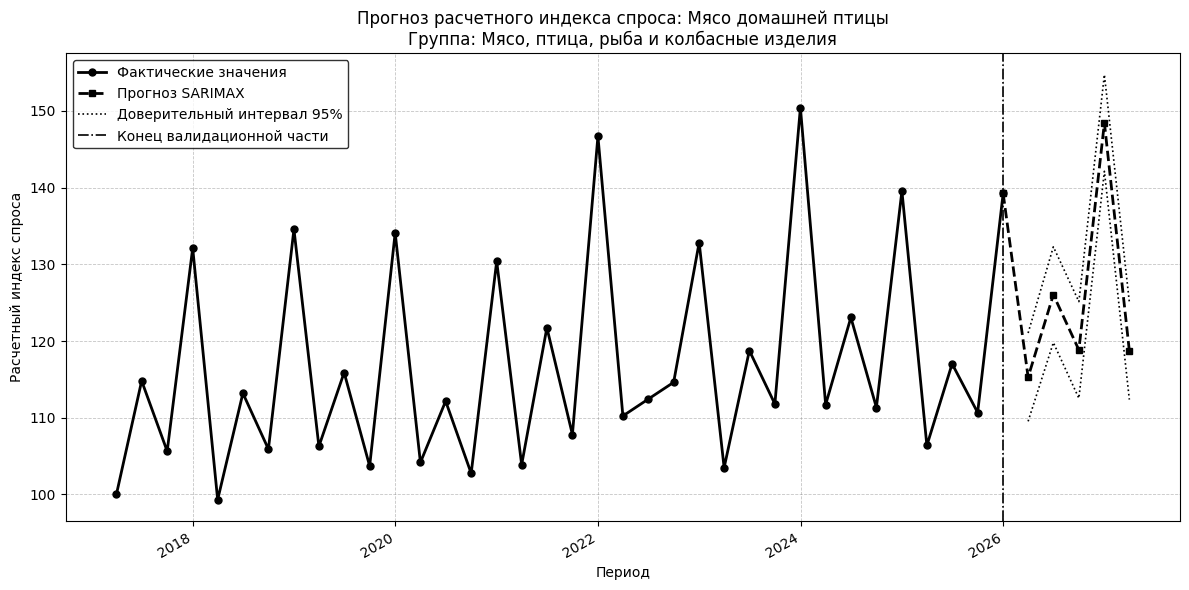

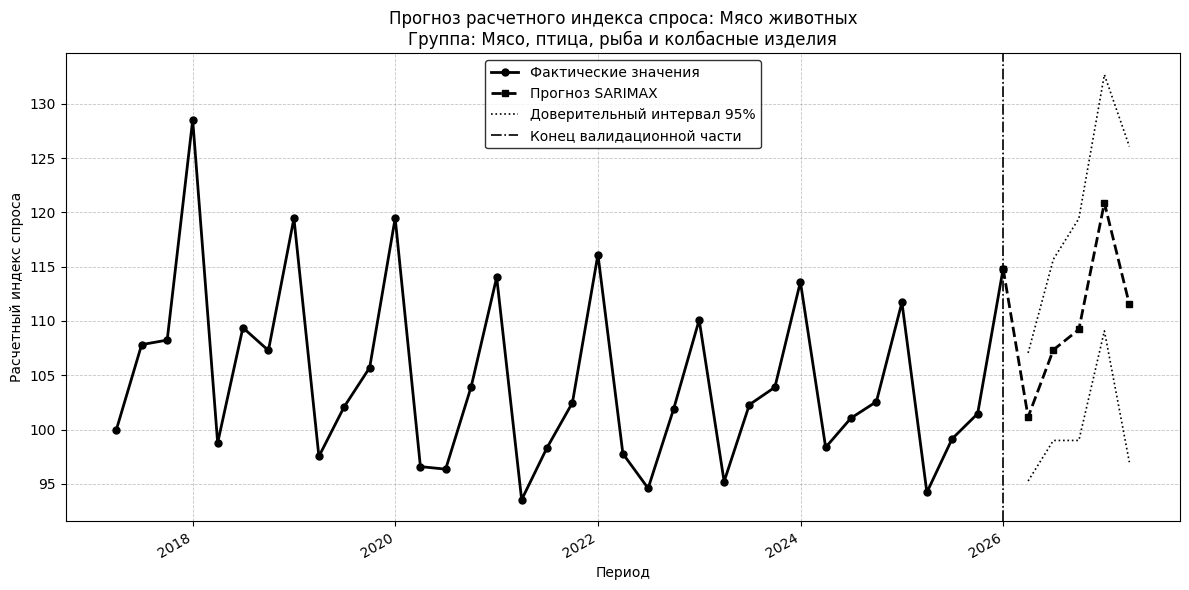

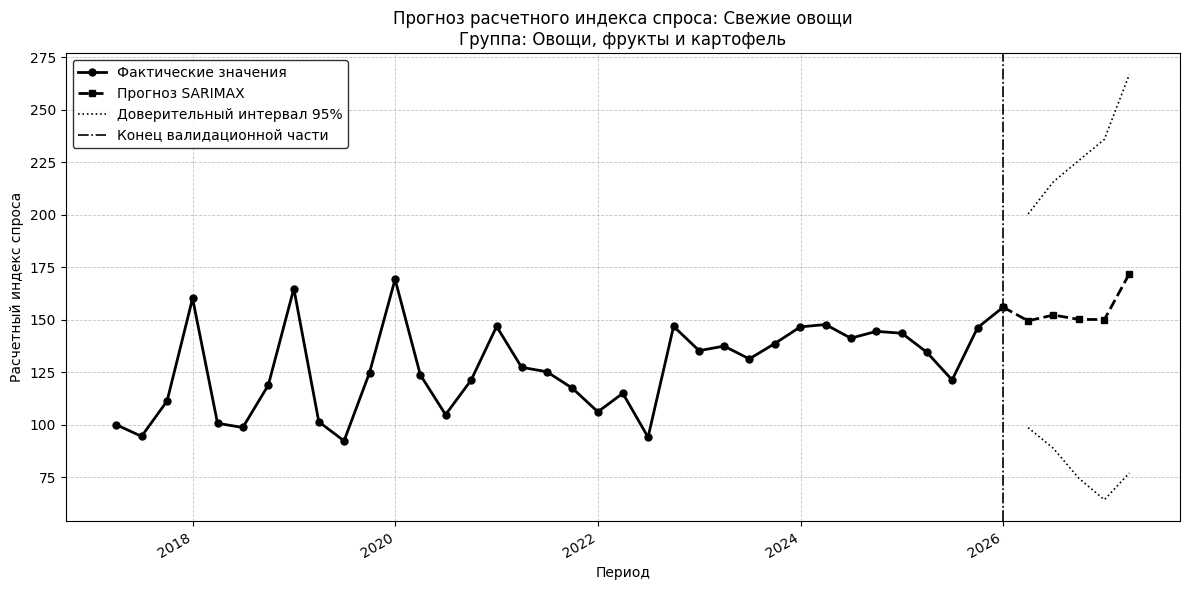

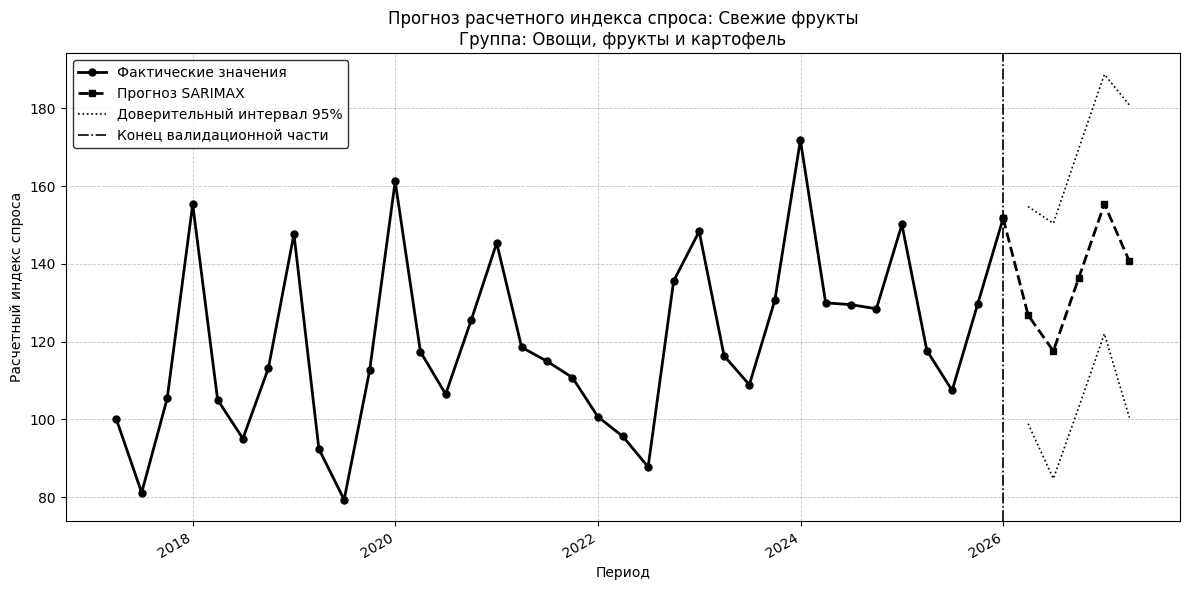

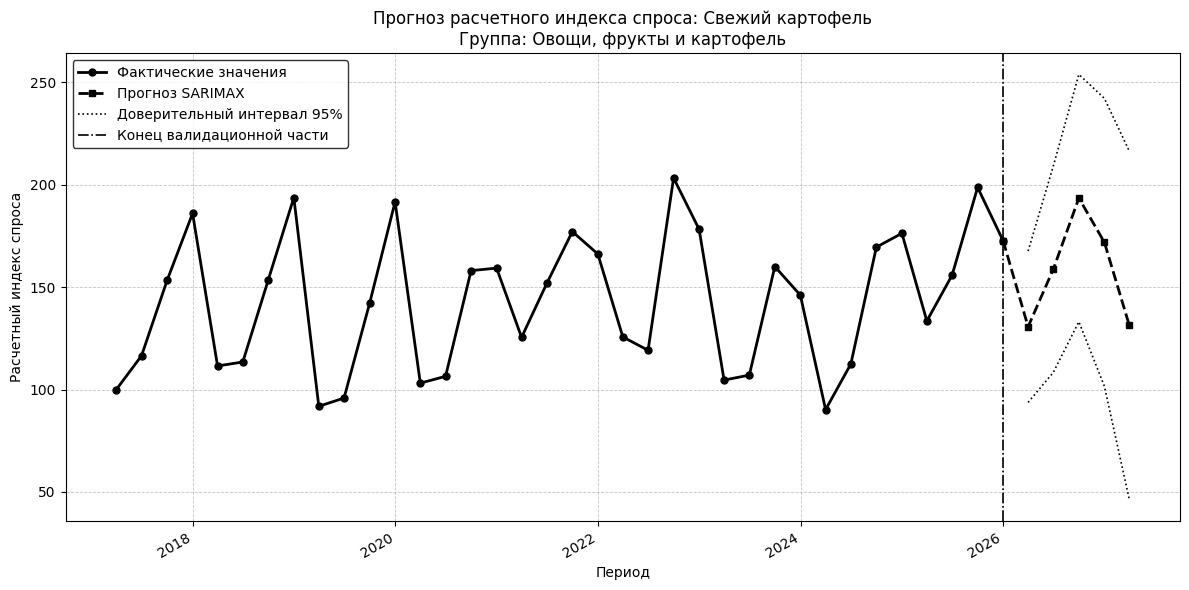

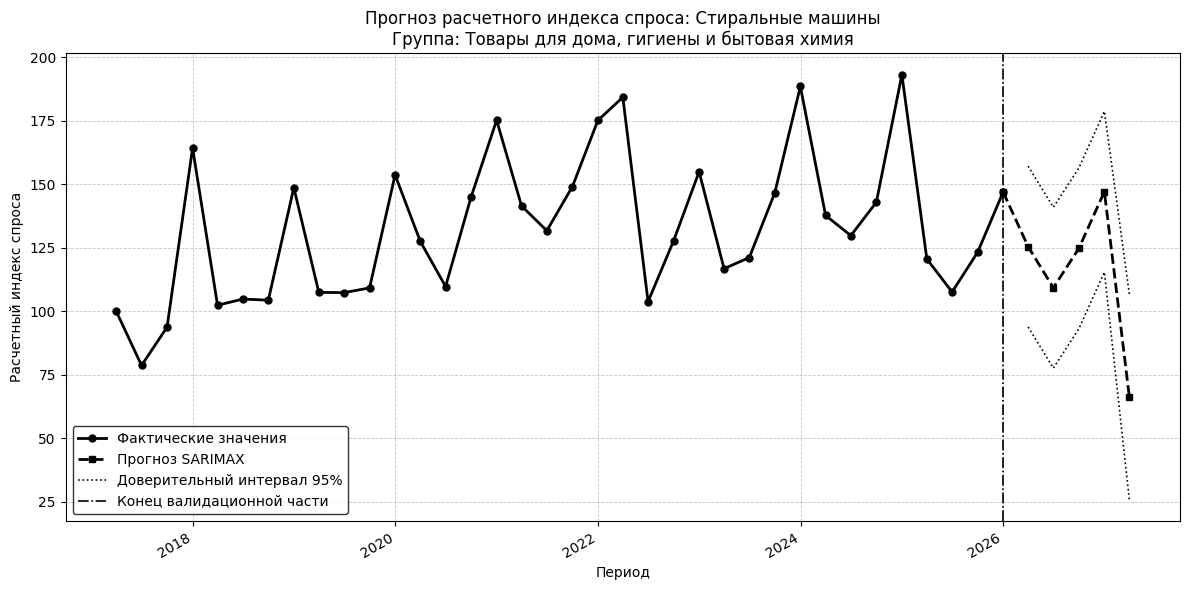

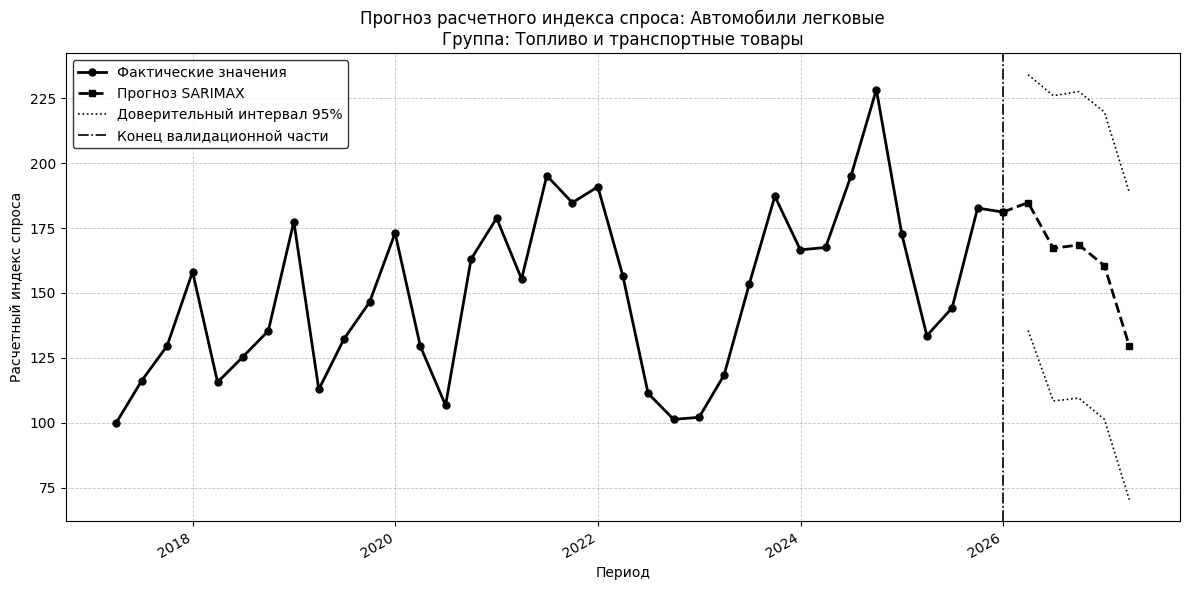

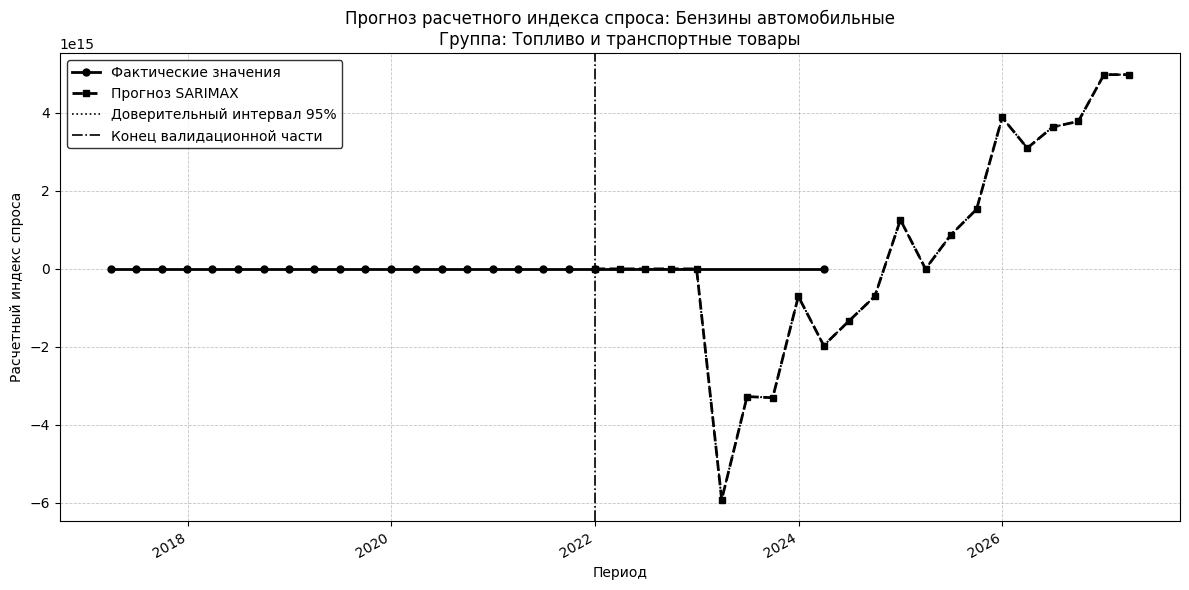

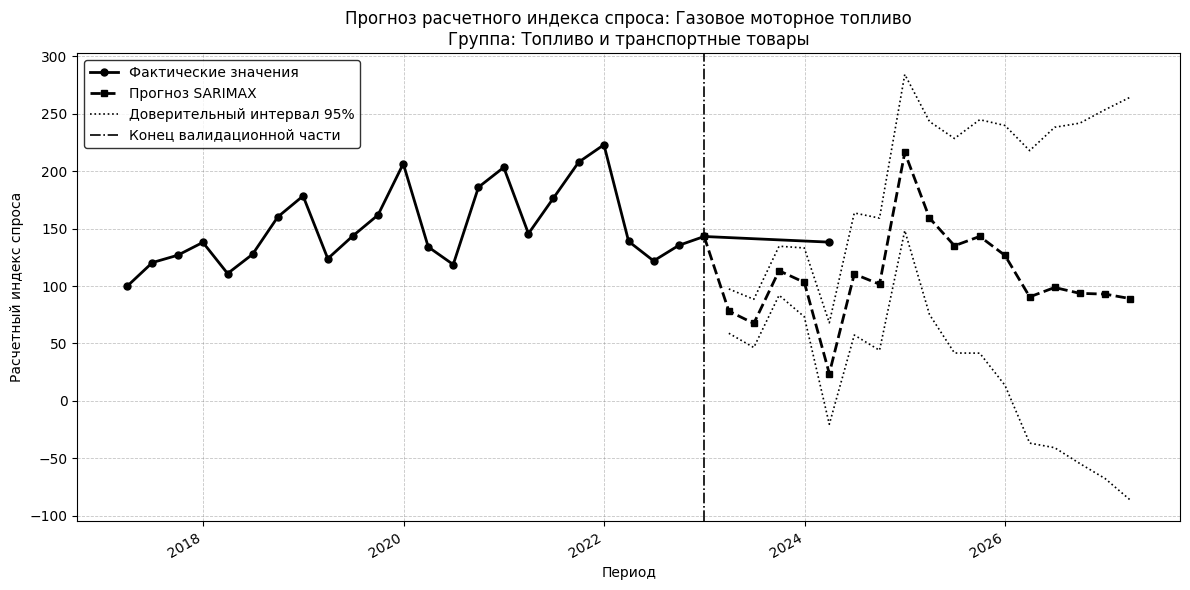

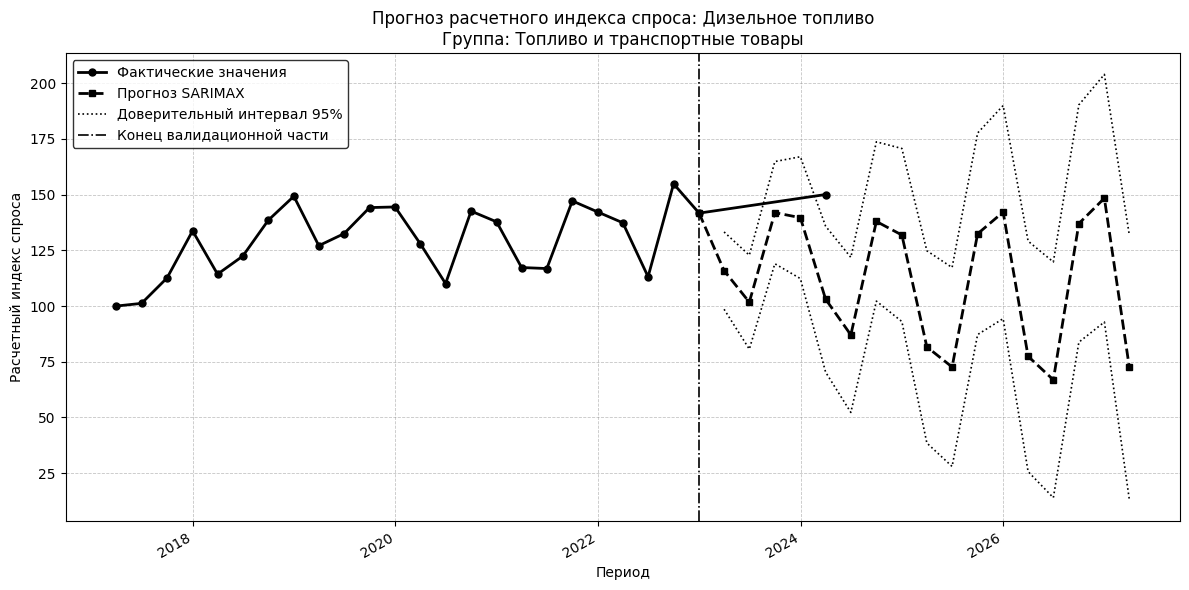

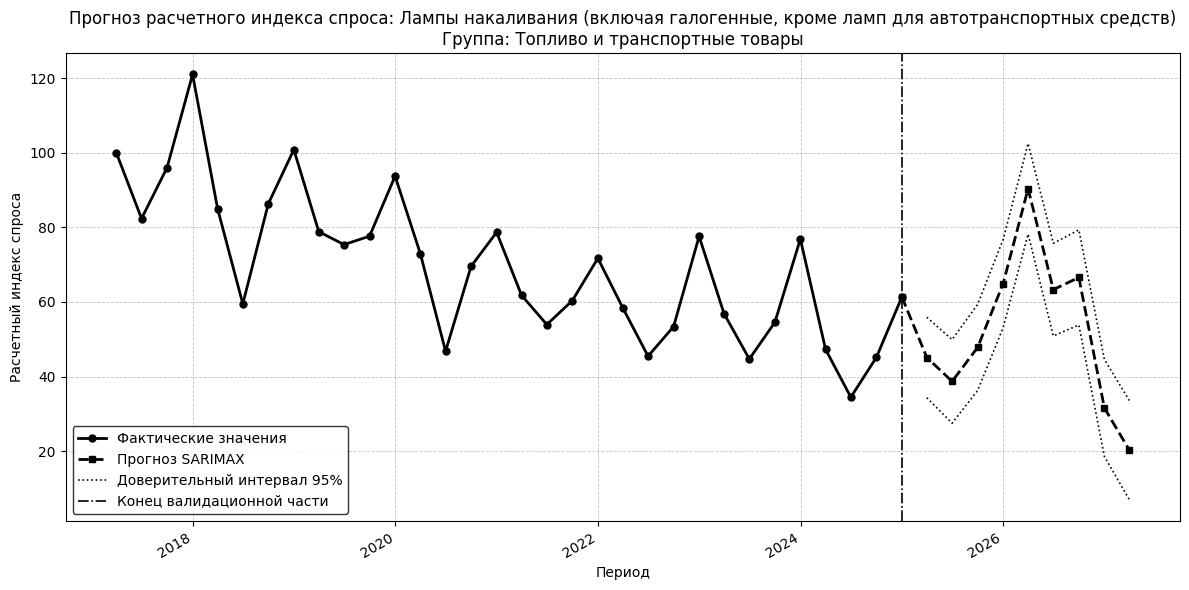

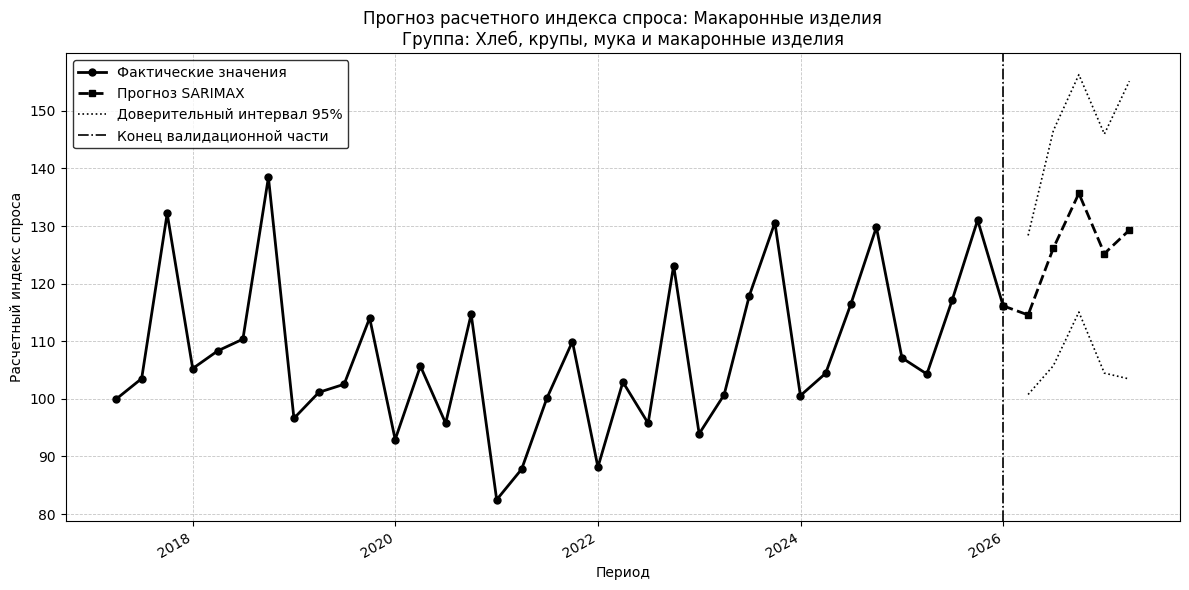

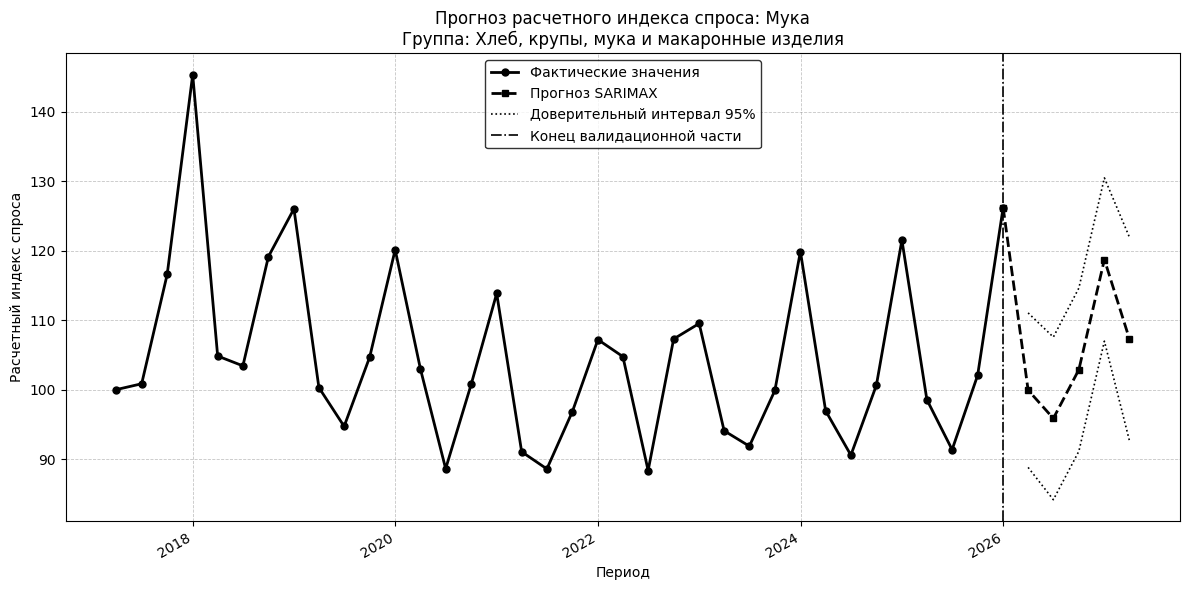

Графиков построено: 18
Папка PNG: /home/senya/projects/diplom/dataset/sarimax_aggressive_exog_selection/future_forecast_plots_bw
PDF: /home/senya/projects/diplom/dataset/sarimax_aggressive_exog_selection/sarimax_future_forecast_to_2027Q1_plots_bw.pdf


In [33]:
from pathlib import Path

import re

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages

from IPython.display import display

plot_dir = result_dir / "future_forecast_plots_bw"

plot_dir.mkdir(parents=True, exist_ok=True)

charts_pdf = result_dir / "sarimax_future_forecast_to_2027Q1_plots_bw.pdf"


def file_name(value):

    text = re.sub(r'[\\/*?:"<>|]', "_", str(value))

    return re.sub(r"\s+", "_", text)[:120]


def history_for_plots():

    hist = collapse_rows(load_data())

    hist["period"] = hist["period"].astype("period[Q]")

    hist["period_end"] = hist["period"].dt.to_timestamp(how="end").dt.normalize()

    return hist[hist[target].notna()].copy()


def forecast_for_plots():

    fc = (
        future_forecast.copy()
        if "future_forecast" in globals() and not future_forecast.empty
        else pd.read_csv(future_file)
    )

    fc["period"] = fc["period"].astype("period[Q]")

    fc["period_end"] = fc["period"].dt.to_timestamp(how="end").dt.normalize()

    for col in [
        "forecast_target_demand_index",
        "forecast_lower_95",
        "forecast_upper_95",
    ]:

        fc[col] = pd.to_numeric(fc[col], errors="coerce")

    return fc


history_plot = history_for_plots()

forecast_plot = forecast_for_plots()


def forecast_line(actual, forecast, name):

    val_end = pd.Period(forecast["validation_end"].iloc[0], freq="Q")

    anchor = actual[actual["period"] == val_end].copy()

    if anchor.empty:

        anchor = actual.tail(1).copy()

    anchor = anchor.iloc[[0]].copy()

    group = forecast["group_name"].iloc[0] if "group_name" in forecast.columns else ""

    start = pd.DataFrame(
        {
            "product_name": [name],
            "group_name": [group],
            "period": [anchor["period"].iloc[0]],
            "period_end": [anchor["period_end"].iloc[0]],
            "forecast_target_demand_index": [anchor[target].iloc[0]],
            "forecast_lower_95": [np.nan],
            "forecast_upper_95": [np.nan],
            "validation_end": [str(val_end)],
        }
    )

    return pd.concat([start, forecast], ignore_index=True).sort_values("period")


def make_chart(name):

    actual = (
        history_plot[history_plot["product_name"] == name].sort_values("period").copy()
    )

    forecast = (
        forecast_plot[forecast_plot["product_name"] == name]
        .sort_values("period")
        .copy()
    )

    if actual.empty or forecast.empty:

        return None

    val_end = pd.Period(forecast["validation_end"].iloc[0], freq="Q")

    val_date = val_end.to_timestamp(how="end").normalize()

    group = forecast["group_name"].iloc[0] if "group_name" in forecast.columns else ""

    line = forecast_line(actual, forecast, name)

    fig, ax = plt.subplots(figsize=(12, 6))

    fig.patch.set_facecolor("white")

    ax.set_facecolor("white")

    ax.plot(
        actual["period_end"],
        actual[target],
        marker="o",
        markersize=5,
        linewidth=2,
        linestyle="-",
        color="black",
        label="Фактические значения",
    )

    ax.plot(
        line["period_end"],
        line["forecast_target_demand_index"],
        marker="s",
        markersize=5,
        linewidth=2,
        linestyle="--",
        color="black",
        label="Прогноз SARIMAX",
    )

    ax.plot(
        forecast["period_end"],
        forecast["forecast_lower_95"],
        linewidth=1.2,
        linestyle=":",
        color="black",
        label="Доверительный интервал 95%",
    )

    ax.plot(
        forecast["period_end"],
        forecast["forecast_upper_95"],
        linewidth=1.2,
        linestyle=":",
        color="black",
    )

    ax.axvline(
        val_date,
        linestyle="-.",
        linewidth=1.2,
        color="black",
        label="Конец валидационной части",
    )

    title = f"Прогноз расчетного индекса спроса: {name}"

    if pd.notna(group) and str(group).strip() != "":

        title += f"\nГруппа: {group}"

    ax.set_title(title)

    ax.set_xlabel("Период")

    ax.set_ylabel("Расчетный индекс спроса")

    ax.grid(True, linestyle="--", linewidth=0.6, color="gray", alpha=0.45)

    ax.legend(frameon=True, facecolor="white", edgecolor="black")

    fig.autofmt_xdate()

    fig.tight_layout()

    return fig


created = []

products = forecast_plot["product_name"].dropna().drop_duplicates().tolist()

for name in products:

    fig = make_chart(name)

    if fig is None:

        continue

    path = plot_dir / f"{file_name(name)}.png"

    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")

    created.append(path)

    display(fig)

    plt.close(fig)

with PdfPages(charts_pdf) as pdf:

    for name in products:

        fig = make_chart(name)

        if fig is None:

            continue

        pdf.savefig(fig, bbox_inches="tight", facecolor="white")

        plt.close(fig)

print(f"Графиков построено: {len(created)}")

print(f"Папка PNG: {plot_dir}")

print(f"PDF: {charts_pdf}")

## Блок 8. Таблицы для практической части

In [34]:
from pathlib import Path

import pandas as pd

import numpy as np

table_dir = data_dir / "diploma_tables"

table_dir.mkdir(parents=True, exist_ok=True)

data = collapse_rows(load_data())

data["period"] = data["period"].astype(str)

sample_cols = [
    "period",
    "group_name",
    "product_name",
    "consumer_price_index",
    "physical_volume_index",
    "stock_days_mean",
    "stock_value_mean_thousand_rub",
    "income_index",
    target,
]

sample_cols = [col for col in sample_cols if col in data.columns]

sample_table = (
    data[sample_cols]
    .dropna(subset=[target])
    .sort_values(["group_name", "product_name", "period"])
    .groupby("group_name", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

obs_table = (
    data[data[target].notna()]
    .groupby(["group_name", "product_name"], as_index=False)
    .agg(
        observations_count=(target, "count"),
        first_period=("period", "min"),
        last_period=("period", "max"),
    )
    .sort_values(["group_name", "product_name"])
)

sample_table.to_csv(
    table_dir / "sample_training_data.csv", index=False, encoding="utf-8-sig"
)

obs_table.to_csv(
    table_dir / "product_observations.csv", index=False, encoding="utf-8-sig"
)

display(sample_table)

display(obs_table)

,period,group_name,product_name,consumer_price_index,physical_volume_index,stock_days_mean,stock_value_mean_thousand_rub,income_index,target_demand_index
0,2017Q1,"Бакалея, масло, сахар, чай, соль",Маргариновая продукция,101.497798,95.09,36.863333,1.318030e+09,100.0,100.0
1,2017Q1,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",109.561625,97.62,36.863333,1.318030e+09,100.0,100.0
2,2017Q1,"Мясо, птица, рыба и колбасные изделия",Мясо домашней птицы,102.712722,96.81,36.863333,1.318030e+09,100.0,100.0
3,2017Q1,"Овощи, фрукты и картофель",Свежие овощи,89.049697,112.18,36.863333,1.318030e+09,100.0,100.0
4,2017Q1,"Товары для дома, гигиены и бытовая химия",Стиральные машины,106.914674,102.85,36.863333,1.318030e+09,100.0,100.0
5,2017Q1,Топливо и транспортные товары,Автомобили легковые,105.627924,101.35,36.863333,1.318030e+09,100.0,100.0
6,2017Q1,"Хлеб, крупы, мука и макаронные изделия",Макаронные изделия,102.445699,101.60,36.863333,1.318030e+09,100.0,100.0


,group_name,product_name,observations_count,first_period,last_period
0,"Бакалея, масло, сахар, чай, соль",Маргариновая продукция,36,2017Q1,2025Q4
1,"Бакалея, масло, сахар, чай, соль",Чай,36,2017Q1,2025Q4
2,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",36,2017Q1,2025Q4
3,Молочная продукция и яйца,Молоко питьевое,36,2017Q1,2025Q4
4,Молочная продукция и яйца,сыры,36,2017Q1,2025Q4
5,"Мясо, птица, рыба и колбасные изделия",Мясо домашней птицы,36,2017Q1,2025Q4
6,"Мясо, птица, рыба и колбасные изделия",Мясо животных,36,2017Q1,2025Q4
7,"Овощи, фрукты и картофель",Свежие овощи,36,2017Q1,2025Q4
8,"Овощи, фрукты и картофель",Свежие фрукты,36,2017Q1,2025Q4
9,"Овощи, фрукты и картофель",Свежий картофель,36,2017Q1,2025Q4


In [ ]:
q